# Embeddings: Words as Coordinates — companion notebook

Chapter 3 of *Applied Natural Language Processing — From Tokens to Agents*.
Read the chapter first: **[Embeddings: Words as Coordinates](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/03-embeddings.html)**.

The chapter builds a word space twice, first by counting and then by predicting, and then
spends as long on what the space gets wrong as on what it gets right. This notebook runs
the chapter's own code, in the chapter's order, so you can watch its numbers appear:

1. **Counting**: co-occurrence, PPMI and SVD on ten sentences, every number checkable by hand.
2. **Predicting**: skip-gram with negative sampling, one update by hand and then about sixty
   lines of NumPy trained on `text8`.
3. **GloVe** pretrained vectors, the analogy test and what it hides.
4. **fastText** subwords on Turkish and English Wikipedia.
5. **Documents as vectors** on 20 Newsgroups.
6. **The geometry's defects**: relatedness, anisotropy, frequency, bias.
7. **Intrinsic evaluation**, and why coverage has to be reported beside a score.

**How to read the numbers.** Everything printed below is what *this run* produced. Where the
chapter prints the same quantity, the cell prints the book's value beside it and says
whether the two match at the book's printed precision. Timings depend on your machine;
read them as orders of magnitude.

**Runtime and downloads.** About 13 minutes on a laptop CPU (Apple M-series) for a full
run, ten of them the from-scratch word2vec training in section 3. With
`ANLP_SKIP_HEAVY=1`, about 3 minutes including the downloads. Everything downloaded is cached under
`data/cache/` next to this notebook:

| what | size | heavy? |
|:--|--:|:--|
| `glove-wiki-gigaword-100` (gensim-data) | 134.3 MB | **yes**: skipped under `ANLP_SKIP_HEAVY=1` |
| `glove-wiki-gigaword-50` (gensim-data) | 69.2 MB | no (used for intuition check 1, and as the skip-mode substitute) |
| `text8` (gensim-data) | 33.2 MB | no; but *training* on it takes about 10 minutes, and that cell **is** heavy |
| Turkish and English Wikipedia samples (Hugging Face) | about 23 MB of JSON | no |
| 20 Newsgroups (scikit-learn) | about 14 MB | no |
| SimLex-999 | 17 kB | no |

The chapter uses no multi-gigabyte model; `word2vec-google-news-300` (1.74 GB) appears
nowhere in it, so nothing here needs one.

**`ANLP_SKIP_HEAVY=1`** (CI sets it) makes the two heavy cells degrade instead of stopping:
the NumPy training loop runs 150 batches as a smoke test, and every GloVe cell uses
`glove-wiki-gigaword-50` instead of the 100-dimensional vectors. Cells that depend on
either say so and do not compare themselves with the book.

## 1. Setup

The first cell records the interpreter and package versions this run used. The chapter's
status note names `gensim` 4.4, `scikit-learn` 1.9 and NumPy 2.5 on Python 3.12. If your
numbers differ from the ones saved in this notebook, compare this cell first.

`GENSIM_DATA_DIR` is set before `gensim.downloader` is imported, because the downloader
reads it once, at import; that is what puts gensim's downloads in this notebook's cache
instead of `~/gensim-data`.

In [1]:
import contextlib
import gzip
import hashlib
import io
import json
import math
import os
import platform
import re
import time
import zipfile
import zlib
from collections import Counter
from importlib.metadata import version
from pathlib import Path

import numpy as np
import requests

SKIP_HEAVY = os.environ.get("ANLP_SKIP_HEAVY") == "1"
CACHE = Path("data/cache")
CACHE.mkdir(parents=True, exist_ok=True)
os.environ["GENSIM_DATA_DIR"] = str((CACHE / "gensim-data").resolve())

import gensim.downloader as api          # noqa: E402  (must follow GENSIM_DATA_DIR)
import matplotlib.pyplot as plt          # noqa: E402

print(f"Python        {platform.python_version()}  ({platform.system()} {platform.machine()})")
for pkg in ["numpy", "scipy", "scikit-learn", "gensim", "matplotlib", "requests"]:
    print(f"{pkg:<13} {version(pkg)}")
print("\nANLP_SKIP_HEAVY", "= 1: heavy cells skip or use labelled substitutes" if SKIP_HEAVY
      else "is not set: every cell runs in full")

Python        3.12.13  (Darwin arm64)
numpy         2.5.2
scipy         1.18.1
scikit-learn  1.9.0
gensim        4.4.0
matplotlib    3.11.2
requests      2.34.2

ANLP_SKIP_HEAVY is not set: every cell runs in full


Three helpers used throughout.

- `vs_book` prints this run's number beside the book's and compares them at the book's
  printed precision. When a cell is running on a substitute (a different corpus, or the
  skip-mode vectors), it says *not comparable* instead of pretending to check.
- `vs_book_line` does the same for a printed line such as a neighbour list.
- `quiet_gensim` needs a word of explanation. While training, `gensim` 4.4.0 sometimes
  prints `Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'` with no
  traceback. No Python exception occurred: gensim's Cython code declares the BLAS
  dot-product function as `except -1`, so whenever a dot product comes out at exactly
  −1.0 Cython takes its error path and prints that note. It does not stop training. The
  helper collects those lines and prints how many there were, so they do not bury the
  output.

In [2]:
def vs_book(label, ours, book, fmt="{}", note=None):
    """This run's value beside the book's, compared at the book's printed precision."""
    ours_s, book_s = fmt.format(ours), fmt.format(book)
    if note:
        verdict = f"not comparable: {note}"
    else:
        verdict = "same as the book" if ours_s == book_s else "DIFFERS from the book"
    print(f"{label:<36} this run {ours_s:>10}   book {book_s:>10}   {verdict}")


def vs_book_line(label, ours, book, note=None):
    """The same comparison for one printed line, such as a neighbour list."""
    if note:
        print(f"  {label:<12} {ours}\n  {'  book':<12} {book}   [not comparable: {note}]")
    elif ours == book:
        print(f"  {label:<12} {ours}   [same as the book]")
    else:
        print(f"  {label:<12} {ours}   [DIFFERS]\n  {'  book':<12} {book}")


@contextlib.contextmanager
def quiet_gensim(what):
    """Collect gensim's 'Exception ignored in our_dot_float' notes and print a count instead."""
    buffer = io.StringIO()
    with contextlib.redirect_stderr(buffer):
        yield
    lines = buffer.getvalue().splitlines()
    notes = sum("Exception ignored in" in line for line in lines)
    print(f"({what}: gensim printed its 'Exception ignored in our_dot_float' note {notes} times)")
    for line in lines:
        if line.strip() and "Exception ignored in" not in line:
            print(line)

## 2. Count first: co-occurrence, PPMI, SVD

[Chapter section](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/03-embeddings.html#count-first-co-occurrence-ppmi-svd). Three steps: count what appears
near what, reweight the counts so common words stop dominating, then factorize. The corpus
is ten sentences, small enough to check every number.

The next cell is the chapter's code, line for line.

In [3]:
import numpy as np

corpus = [
    "the king rules the castle",
    "the queen rules the castle",
    "the king eats an apple",
    "the queen eats a banana",
    "the royal castle is grand",
    "a banana is sweet fruit",
    "an apple is sweet fruit",
    "the man eats an apple",
    "the woman eats a banana",
    "the king and queen are royal",
]

tokens = [s.split() for s in corpus]
vocab = sorted({w for s in tokens for w in s})
idx = {w: i for i, w in enumerate(vocab)}
V = len(vocab)
print("sentences:", len(corpus), " vocabulary:", V)
print(vocab)

print()
vs_book("sentences", len(corpus), 10)
vs_book("vocabulary", V, 19)
vs_book("tokens in the corpus", sum(len(s) for s in tokens), 51)
BOOK_VOCAB = ['a', 'an', 'and', 'apple', 'are', 'banana', 'castle', 'eats', 'fruit', 'grand',
              'is', 'king', 'man', 'queen', 'royal', 'rules', 'sweet', 'the', 'woman']
print("vocabulary list:", "same as the book" if vocab == BOOK_VOCAB else "DIFFERS from the book")

sentences: 10  vocabulary: 19
['a', 'an', 'and', 'apple', 'are', 'banana', 'castle', 'eats', 'fruit', 'grand', 'is', 'king', 'man', 'queen', 'royal', 'rules', 'sweet', 'the', 'woman']

sentences                            this run         10   book         10   same as the book
vocabulary                           this run         19   book         19   same as the book
tokens in the corpus                 this run         51   book         51   same as the book
vocabulary list: same as the book


### Step 1: count what appears near what

Window 2 means two tokens to the left and two to the right. The first four lines are the
chapter's; the printing below them is ours, because the chapter shows the table but not the
code that printed it.

**What to look at:** `king` and `queen` have nearly the same row, and so do `apple` and
`banana`. Then the row totals, where `the` dominates.

In [4]:
W = 2
C = np.zeros((V, V))
for sent in tokens:
    for i, w in enumerate(sent):
        for j in range(max(0, i - W), min(len(sent), i + W + 1)):
            if i != j:
                C[idx[w], idx[sent[j]]] += 1

SHOW_ROWS = ["king", "queen", "apple", "banana"]
SHOW_COLS = ["eats", "rules", "royal", "sweet", "the", "castle"]
BOOK_COUNTS = {"king": [1, 1, 0, 0, 4, 0], "queen": [1, 1, 1, 0, 3, 0],
               "apple": [2, 0, 0, 1, 0, 0], "banana": [2, 0, 0, 1, 0, 0]}

print("### raw co-occurrence, a few rows")
print(" " * 8 + "".join(f"{c:>8}" for c in SHOW_COLS))
for r in SHOW_ROWS:
    row_vals = [int(C[idx[r], idx[c]]) for c in SHOW_COLS]
    verdict = "same as the book" if row_vals == BOOK_COUNTS[r] else f"DIFFERS: book {BOOK_COUNTS[r]}"
    print(f"{r:<8}" + "".join(f"{x:>8}" for x in row_vals) + f"    [{verdict}]")

print("\n### the same problem as chapter 2: 'the' dominates")
BOOK_TOTALS = [("the", 22), ("eats", 16), ("is", 11), ("queen", 10), ("king", 9), ("a", 8)]
row_totals = C.sum(axis=1)
ours_totals = [(vocab[i], int(row_totals[i])) for i in np.argsort(-row_totals, kind="stable")[:6]]
for w, n in ours_totals:
    print(f"  {w:<8} total co-occurrences {n:>5}")
print("[same as the book]" if ours_totals == BOOK_TOTALS else f"[DIFFERS: book {BOOK_TOTALS}]")

### raw co-occurrence, a few rows
            eats   rules   royal   sweet     the  castle
king           1       1       0       0       4       0    [same as the book]
queen          1       1       1       0       3       0    [same as the book]
apple          2       0       0       1       0       0    [same as the book]
banana         2       0       0       1       0       0    [same as the book]

### the same problem as chapter 2: 'the' dominates
  the      total co-occurrences    22
  eats     total co-occurrences    16
  is       total co-occurrences    11
  queen    total co-occurrences    10
  king     total co-occurrences     9
  a        total co-occurrences     8
[same as the book]


### Step 2: PPMI, worked by hand first

The chapter works two cells of the matrix by hand before running the formula:
`apple`–`sweet` (seen once) and `king`–`the` (seen four times). All four numbers come from
the matrix $C$ above: the cell itself, its row total, its column total and the grand total
$N$. The chapter also checks $N$ by counting pairs per sentence: nine five-token sentences
give 14 pairs each and the one six-token sentence gives 18.

**What to look at:** the pair seen once scores *higher* than the pair seen four times.

In [5]:
N_pairs = C.sum()
vs_book("N, from the matrix", int(N_pairs), 144)
vs_book("N, from 9 x 14 + 18", 9 * 14 + 18, 144)
print()

BOOK_BY_HAND = {("apple", "sweet"): (1, 7, 6, 0.29, 3.43, 1.23),
                ("king", "the"):    (4, 9, 22, 1.38, 2.91, 1.07)}
for (w, c), (b_obs, b_row, b_col, b_exp, b_ratio, b_pmi) in BOOK_BY_HAND.items():
    observed = C[idx[w], idx[c]]
    row_total, col_total = C[idx[w]].sum(), C[:, idx[c]].sum()
    expected = row_total * col_total / N_pairs
    print(f"{w} - {c}")
    vs_book("  observed", int(observed), b_obs)
    vs_book("  row total", int(row_total), b_row)
    vs_book("  column total", int(col_total), b_col)
    vs_book("  expected = row x col / N", expected, b_exp, "{:.2f}")
    vs_book("  ratio observed / expected", observed / expected, b_ratio, "{:.2f}")
    vs_book("  PMI = log ratio", math.log(observed / expected), b_pmi, "{:.2f}")

N, from the matrix                   this run        144   book        144   same as the book
N, from 9 x 14 + 18                  this run        144   book        144   same as the book

apple - sweet
  observed                           this run          1   book          1   same as the book
  row total                          this run          7   book          7   same as the book
  column total                       this run          6   book          6   same as the book
  expected = row x col / N           this run       0.29   book       0.29   same as the book
  ratio observed / expected          this run       3.43   book       3.43   same as the book
  PMI = log ratio                    this run       1.23   book       1.23   same as the book
king - the
  observed                           this run          4   book          4   same as the book
  row total                          this run          9   book          9   same as the book
  column total                    

Now the chapter's PPMI code, and the same cells as the raw table above.

**What to look at:** `apple`–`sweet` was the smallest non-zero count in its row; now it is
the largest value.

In [6]:
total = C.sum()
row = C.sum(axis=1, keepdims=True)
col = C.sum(axis=0, keepdims=True)
with np.errstate(divide="ignore", invalid="ignore"):
    pmi = np.log((C * total) / (row * col))
pmi[~np.isfinite(pmi)] = 0.0
PPMI = np.maximum(pmi, 0.0)

BOOK_PPMI = {"king":   ["0.00", "0.69", "0.00", "0.00", "1.07", "0.00"],
             "queen":  ["0.00", "0.59", "1.06", "0.00", "0.67", "0.00"],
             "apple":  ["0.94", "0.00", "0.00", "1.23", "0.00", "0.00"],
             "banana": ["0.94", "0.00", "0.00", "1.23", "0.00", "0.00"]}
print("### PPMI for the same cells")
print(" " * 8 + "".join(f"{c:>8}" for c in SHOW_COLS))
for r in SHOW_ROWS:
    row_vals = [f"{PPMI[idx[r], idx[c]]:.2f}" for c in SHOW_COLS]
    verdict = "same as the book" if row_vals == BOOK_PPMI[r] else f"DIFFERS: book {BOOK_PPMI[r]}"
    print(f"{r:<8}" + "".join(f"{x:>8}" for x in row_vals) + f"    [{verdict}]")

### PPMI for the same cells
            eats   rules   royal   sweet     the  castle
king        0.00    0.69    0.00    0.00    1.07    0.00    [same as the book]
queen       0.00    0.59    1.06    0.00    0.67    0.00    [same as the book]
apple       0.94    0.00    0.00    1.23    0.00    0.00    [same as the book]
banana      0.94    0.00    0.00    1.23    0.00    0.00    [same as the book]


### Step 3: factorize

First the neighbours the PPMI rows already give, by cosine similarity, in 19 dimensions.
Then the chapter's two SVD lines with $d = 5$, and the neighbours after compression. The
neighbour-printing helper is ours; ties are broken by vocabulary order.

**What to look at:** `apple` → `man` before, the one-sentence accident. After SVD `banana`
moves to first place, although the `apple`–`man` cosine *rises*.

In [7]:
def neighbours(M, word, k=4):
    """Nearest neighbours of `word` by cosine over the rows of M (toy vocabulary)."""
    X = M / np.linalg.norm(M, axis=1, keepdims=True)
    sims = X @ X[idx[word]]
    order = [i for i in np.argsort(-sims, kind="stable") if i != idx[word]][:k]
    return ", ".join(f"{vocab[i]} {sims[i]:.2f}" for i in order)


def cosine(M, a, b):
    x, y = M[idx[a]], M[idx[b]]
    return float(x @ y / (np.linalg.norm(x) * np.linalg.norm(y)))


print("### nearest neighbours before factorization (PPMI rows, 19-D)")
BOOK_NN_PPMI = {"king": "queen 0.55, are 0.55, man 0.45, the 0.37",
                "apple": "man 0.79, fruit 0.52, banana 0.40, is 0.31",
                "eats": "a 0.55, an 0.55, man 0.34, woman 0.34"}
for w, book_line in BOOK_NN_PPMI.items():
    vs_book_line(w, neighbours(PPMI, w), book_line)

d = 5
U, S, Vt = np.linalg.svd(PPMI, full_matrices=False)
emb = U[:, :d] * S[:d]

print("\n### singular values (how much structure each dimension carries)")
ours_sv = "  ".join(f"{s:.2f}" for s in S[:8])
vs_book_line("first 8", ours_sv, "5.75  4.76  4.03  3.71  3.64  3.08  3.03  2.80")
share = S**2 / (S**2).sum()
vs_book("first 2 dimensions hold, %", 100 * share[:2].sum(), 36.8, "{:.1f}")
vs_book("first 5 dimensions hold, %", 100 * share[:5].sum(), 65.4, "{:.1f}")

print("\n### nearest neighbours after SVD to 5 dimensions")
BOOK_NN_SVD = {"king": "queen 0.90, are 0.88, the 0.74, castle 0.65",
               "apple": "banana 1.00, woman 0.86, man 0.85, fruit 0.74",
               "eats": "an 0.95, a 0.95, man 0.64, woman 0.63",
               "castle": "are 0.82, is 0.80, king 0.65, queen 0.61"}
for w, book_line in BOOK_NN_SVD.items():
    vs_book_line(w, neighbours(emb, w), book_line)

print("\n### the same counts, compressed into five dimensions")
for a, b, book_ppmi, book_svd in [("apple", "banana", 0.40, 1.00),
                                  ("king", "queen", 0.55, 0.90),
                                  ("apple", "man", 0.79, 0.85)]:
    vs_book(f"{a} - {b}, PPMI rows 19-D", cosine(PPMI, a, b), book_ppmi, "{:.2f}")
    vs_book(f"{a} - {b}, SVD 5-D", cosine(emb, a, b), book_svd, "{:.2f}")

### nearest neighbours before factorization (PPMI rows, 19-D)
  king         queen 0.55, are 0.55, man 0.45, the 0.37   [same as the book]
  apple        man 0.79, fruit 0.52, banana 0.40, is 0.31   [same as the book]
  eats         a 0.55, an 0.55, man 0.34, woman 0.34   [same as the book]

### singular values (how much structure each dimension carries)
  first 8      5.75  4.76  4.03  3.71  3.64  3.08  3.03  2.80   [same as the book]
first 2 dimensions hold, %           this run       36.8   book       36.8   same as the book
first 5 dimensions hold, %           this run       65.4   book       65.4   same as the book

### nearest neighbours after SVD to 5 dimensions
  king         queen 0.90, are 0.88, the 0.74, castle 0.65   [same as the book]
  apple        banana 1.00, woman 0.86, man 0.85, fruit 0.74   [same as the book]
  eats         an 0.95, a 0.95, man 0.64, woman 0.63   [same as the book]
  castle       are 0.82, is 0.80, king 0.65, queen 0.61   [same as the book]

### the 

**Reading it.** Five directions out of nineteen carry about two thirds of the sum of
squares. The chapter is careful that this is a share of $\lVert X \rVert_F^2$, not of
variance, because the PPMI matrix is never centred.

The chapter's "compression" box compares cosines in a *two*-dimensional SVD space, and
warns about a detail that returns at the end of the chapter: every word has a negative
first coordinate. The next cell checks both, then draws the chapter's figure, which plots
dimensions 2 and 3 for that reason. The figure's coordinates are compared with the ones
the chapter's widget plots. (A singular vector is defined only up to its sign, so on
another machine an axis could come out flipped.)

### compression
  one-hot / count row : 19 numbers per word
  svd embedding       : 5 numbers per word
king vs queen (2-D)                  this run      0.996   book      0.996   same as the book
king vs banana (2-D)                 this run      0.141   book      0.141   same as the book

words with a negative first coordinate: 19 of 19   (the book: every single word)
figure coordinates: largest difference from the book's widget 0.0005 over 12 words


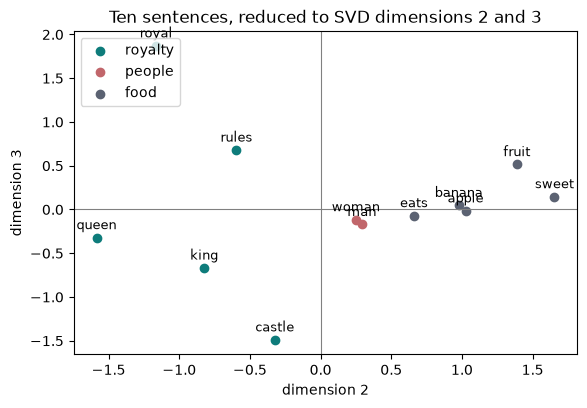

In [8]:
emb2 = U[:, :2] * S[:2]
print("### compression")
print("  one-hot / count row :", V, "numbers per word")
print("  svd embedding       :", d, "numbers per word")
vs_book("king vs queen (2-D)", cosine(emb2, "king", "queen"), 0.996, "{:.3f}")
vs_book("king vs banana (2-D)", cosine(emb2, "king", "banana"), 0.141, "{:.3f}")
first = (U[:, 0] * S[0])
print(f"\nwords with a negative first coordinate: {int((first < 0).sum())} of {V}"
      "   (the book: every single word)")

BOOK_TOY_COORDS = {
    "king": (-0.824, -0.667),
    "queen": (-1.585, -0.321),
    "royal": (-1.163, 1.871),
    "castle": (-0.324, -1.489),
    "rules": (-0.595, 0.68),
    "man": (0.292, -0.17),
    "woman": (0.249, -0.115),
    "apple": (1.026, -0.015),
    "banana": (0.978, 0.048),
    "fruit": (1.388, 0.514),
    "sweet": (1.655, 0.147),
    "eats": (0.661, -0.07),
}

emb3 = U[:, :3] * S[:3]
diffs = [max(abs(emb3[idx[w], 1] - x), abs(emb3[idx[w], 2] - y)) for w, (x, y) in BOOK_TOY_COORDS.items()]
print(f"figure coordinates: largest difference from the book's widget {max(diffs):.4f} "
      f"over {len(diffs)} words")

groups = {"royalty": ["king", "queen", "royal", "castle", "rules"], "people": ["man", "woman"],
          "food": ["apple", "banana", "fruit", "sweet", "eats"]}
fig, ax = plt.subplots(figsize=(6.5, 4.2))
for (label, words), colour in zip(groups.items(), ["#0E7C7B", "#C1666B", "#5B6272"]):
    xs, ys = emb3[[idx[w] for w in words], 1], emb3[[idx[w] for w in words], 2]
    ax.scatter(xs, ys, color=colour, label=label)
    for w, x, y in zip(words, xs, ys):
        ax.annotate(w, (x, y), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=9)
ax.axhline(0, color="grey", lw=0.8)
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("dimension 2")
ax.set_ylabel("dimension 3")
ax.set_title("Ten sentences, reduced to SVD dimensions 2 and 3")
ax.legend(loc="upper left")
plt.show()

## 3. From counting to predicting: word2vec

[Chapter section](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/03-embeddings.html#from-counting-to-predicting-word2vec). Skip-gram takes the centre
word and predicts each word around it. The chapter's widget cuts a sentence into training
pairs; here is the same, for its default sentence, window and centre position.

In [9]:
sentence = "the pump failed during the night shift".split()
WINDOW_DEMO = 2
pairs = [(sentence[i], sentence[j], i)
         for i in range(len(sentence))
         for j in range(max(0, i - WINDOW_DEMO), min(len(sentence), i + WINDOW_DEMO + 1)) if i != j]
centre = 1
print(f"centre '{sentence[centre]}' produces {sum(p[2] == centre for p in pairs)} pairs:",
      [(a, b) for a, b, i in pairs if i == centre])
print(f"the whole sentence produces {len(pairs)} pairs")
print(f"\na 6-billion-token corpus with window 5 gives up to 2 x 5 = 10 pairs per token: "
      f"about {6e9 * 10 / 1e9:.0f} billion (the book: about 60 billion)")

centre 'pump' produces 3 pairs: [('pump', 'the'), ('pump', 'failed'), ('pump', 'during')]
the whole sentence produces 22 pairs

a 6-billion-token corpus with window 5 gives up to 2 x 5 = 10 pairs per token: about 60 billion (the book: about 60 billion)


### Negative sampling, one update by hand

[Chapter section](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/03-embeddings.html#negative-sampling-is-a-logistic-regression). The chapter works one
update in four dimensions: centre word `failed`, true partner `pump`, sampled fake `opera`.
The cell recomputes every number in that paragraph, then moves the vectors with learning
rate 0.05, first updating only the centre vector and then all three, as a real
implementation does.

In [10]:
def sig(z):
    return 1.0 / (1.0 + np.exp(-z))


v_failed = np.array([0.4, -0.2, 0.7, 0.1])
u_pump = np.array([0.5, 0.1, 0.6, -0.3])
u_opera = np.array([-0.3, 0.6, -0.2, 0.4])

z_real, z_fake = v_failed @ u_pump, v_failed @ u_opera
vs_book("failed . pump", z_real, 0.57, "{:.2f}")
vs_book("sigma(0.57)", sig(z_real), 0.639, "{:.3f}")
vs_book("loss, real pair", -np.log(sig(z_real)), 0.448, "{:.3f}")
vs_book("failed . opera", z_fake, -0.34, "{:.2f}")
vs_book("sigma(0.34)", sig(-z_fake), 0.584, "{:.3f}")
vs_book("loss, fake pair", -np.log(sig(-z_fake)), 0.538, "{:.3f}")

r_real, r_fake = sig(z_real) - 1, sig(z_fake) - 0          # prediction minus target
vs_book("residual, pump", r_real, -0.361, "{:.3f}")
vs_book("residual, opera", r_fake, 0.416, "{:.3f}")
g_v = r_real * u_pump + r_fake * u_opera
vs_book_line("g_v", "(" + ", ".join(f"{x:.3f}" for x in g_v) + ")", "(-0.305, 0.213, -0.300, 0.275)")

lr = 0.05
v_new = v_failed - lr * g_v                                 # centre vector only
vs_book("failed . pump, centre updated", v_new @ u_pump, 0.590, "{:.3f}")
vs_book("failed . opera, centre updated", v_new @ u_opera, -0.359, "{:.3f}")
u_pump_new = u_pump - lr * r_real * v_failed                # context vectors too
u_opera_new = u_opera - lr * r_fake * v_failed
vs_book("failed . pump, all updated", v_new @ u_pump_new, 0.603, "{:.3f}")
vs_book("failed . opera, all updated", v_new @ u_opera_new, -0.374, "{:.3f}")
print(f"\nhow much further the full update moved each dot product: "
      f"pump {(v_new @ u_pump_new - z_real) / (v_new @ u_pump - z_real):.2f}x, "
      f"opera {(v_new @ u_opera_new - z_fake) / (v_new @ u_opera - z_fake):.2f}x   "
      "(the book: about 1.6 times)")

failed . pump                        this run       0.57   book       0.57   same as the book
sigma(0.57)                          this run      0.639   book      0.639   same as the book
loss, real pair                      this run      0.448   book      0.448   same as the book
failed . opera                       this run      -0.34   book      -0.34   same as the book
sigma(0.34)                          this run      0.584   book      0.584   same as the book
loss, fake pair                      this run      0.538   book      0.538   same as the book
residual, pump                       this run     -0.361   book     -0.361   same as the book
residual, opera                      this run      0.416   book      0.416   same as the book
  g_v          (-0.305, 0.213, -0.300, 0.275)   [same as the book]
failed . pump, centre updated        this run      0.590   book      0.590   same as the book
failed . opera, centre updated       this run     -0.359   book     -0.359   same as th

**Reading it.** Every number in the chapter's worked update reproduces. The one loose
figure is the closing ratio: the chapter says the full update moves the two dot products
"about 1.6 times as far", and the exact ratios are 1.66 and 1.77.

The chapter's widget lets you drag the dot product and watch the two loss terms. A static
version shows the same point: each term is gentle where the model is already right and
steep where it is badly wrong, which is what keeps the updates self-limiting.

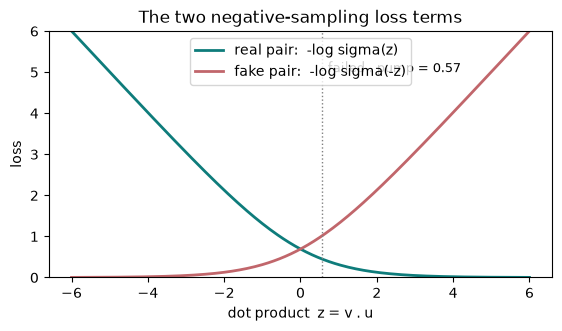

In [11]:
z = np.linspace(-6, 6, 241)
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(z, -np.log(sig(z)), color="#0E7C7B", lw=2, label="real pair:  -log sigma(z)")
ax.plot(z, -np.log(sig(-z)), color="#C1666B", lw=2, label="fake pair:  -log sigma(-z)")
ax.axvline(z_real, color="grey", ls=":", lw=1)
ax.annotate("failed . pump = 0.57", (z_real, 5), xytext=(4, 0), textcoords="offset points", fontsize=9)
ax.set_xlabel("dot product  z = v . u")
ax.set_ylabel("loss")
ax.set_ylim(0, 6)
ax.legend()
ax.set_title("The two negative-sampling loss terms")
plt.show()

### Two details that matter more than the architecture

[Chapter section](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/03-embeddings.html#two-details-that-matter-more-than-the-architecture). The chapter's
table of what subsampling throws away, from the formula in word2vec's C source (the one
the training code below uses), and the paper's different formula beside it. Then the
arithmetic of the 0.75 exponent, and the cost ratio in the negative-sampling figure.

In [12]:
t = 1e-3
print(f"{'share of corpus':<17}{'p_keep (C source)':>19}{'discarded':>11}{'book':>14}{'paper: discard':>17}")
for f, book_keep, book_discard in [(0.05, "0.16", "84%"), (0.01, "0.42", "58%"),
                                   (0.001, "1.00", "0%"), (0.0001, "1.00", "0%")]:
    keep_f = min(1.0, (math.sqrt(f / t) + 1) * t / f)
    ours = f"{keep_f:.2f}  {100 * (1 - keep_f):>5.0f}%"
    paper = max(0.0, 1 - math.sqrt(t / f))
    verdict = "same" if (f"{keep_f:.2f}", f"{100 * (1 - keep_f):.0f}%") == (book_keep, book_discard) else "DIFFERS"
    print(f"{100 * f:>14.2g}%  {keep_f:>18.2f}{100 * (1 - keep_f):>10.0f}%{book_keep + ' / ' + book_discard:>14}"
          f"{100 * paper:>16.0f}%   [{verdict}]")

print()
vs_book("0.5^0.75 is larger than 0.5 by, %", 100 * (0.5**0.75 / 0.5 - 1), 19, "{:.0f}")
vs_book("0.001^0.75 / 0.001", 0.001**0.75 / 0.001, 5.6, "{:.1f}")
vs_book("5000^0.75", 5000**0.75, 595, "{:.0f}")
vs_book("gap narrows by a factor of about", 5000 / 5000**0.75, 8, "{:.0f}")
vs_book("softmax / negative sampling, nearest 1,000", round(400_000 / 6, -3), 67_000, "{:,.0f}")

share of corpus    p_keep (C source)  discarded          book   paper: discard
             5%                0.16        84%    0.16 / 84%              86%   [same]
             1%                0.42        58%    0.42 / 58%              68%   [same]
           0.1%                1.00         0%     1.00 / 0%               0%   [same]
          0.01%                1.00         0%     1.00 / 0%               0%   [same]

0.5^0.75 is larger than 0.5 by, %    this run         19   book         19   same as the book
0.001^0.75 / 0.001                   this run        5.6   book        5.6   same as the book
5000^0.75                            this run        595   book        595   same as the book
gap narrows by a factor of about     this run          8   book          8   same as the book
softmax / negative sampling, nearest 1,000 this run     67,000   book     67,000   same as the book


**Reading it.** At 5% of the corpus the C-source formula keeps 16% of occurrences; the
paper's formula would discard 86% rather than 84%. The two agree on the tail: nothing
below the threshold is touched. The last line is the "roughly 67,000 times cheaper" of the
chapter's figure, 400,000 dot products against 1 + 5; the exact ratio is 66,667.

### Writing it from scratch: the data

[Chapter section](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/03-embeddings.html#writing-it-from-scratch). The chapter trains skip-gram with negative
sampling in about sixty lines of NumPy, on the first 40 million characters of `text8`, a
cleaned dump of English Wikipedia (Matt Mahoney's benchmark file; gensim-data lists no
licence for it, and Wikipedia text is CC BY-SA).

The listing is split across three cells here, so that the cheap part runs even when the
training is skipped. This first cell is the chapter's code up to the training loop, line
for line. The prints after it are ours: the chapter prints these four counts but its
listing does not show the print statements.

**What to look at:** every count should match exactly. The subsampling draw uses
`default_rng(0)`, so even the number of tokens it keeps is fixed.

In [13]:
import gzip, time
from collections import Counter
import numpy as np
import gensim.downloader as api

rng = np.random.default_rng(0)

with gzip.open(api.load("text8", return_path=True), "rt") as f:
    raw = f.read(40_000_000).split()

MIN_COUNT = 20
counts = Counter(raw)
vocab = [w for w, c in counts.most_common() if c >= MIN_COUNT]
idx = {w: i for i, w in enumerate(vocab)}
V = len(vocab)

total = sum(counts[w] for w in vocab)
freq = np.array([counts[w] / total for w in vocab])
keep = np.minimum(1.0, (np.sqrt(freq / 1e-3) + 1) * (1e-3 / freq))

ids = np.array([idx[w] for w in raw if w in idx], dtype=np.int32)
ids = ids[rng.random(len(ids)) < keep[ids]]          # subsampling

noise = freq ** 0.75                                  # the 0.75 exponent
noise /= noise.sum()
cum = np.cumsum(noise)

D, K, WINDOW, EPOCHS, LR0 = 100, 5, 5, 3, 0.02
Wc = ((rng.random((V, D)) - 0.5) / D).astype(np.float32)   # centre vectors
Wo = np.zeros((V, D), dtype=np.float32)                    # context vectors

# Two simplifications, stated so you can undo them. The window is fixed at 5,
# whereas word2vec samples an effective width uniformly from {1..5} for each
# centre, which weights near neighbours more heavily. And pairs are formed
# across the whole token stream, ignoring document boundaries — harmless on
# text8, which is one continuous dump, wrong on a corpus of separate documents.
centres, contexts = [], []
for off in range(1, WINDOW + 1):
    centres.append(ids[:-off]); contexts.append(ids[off:])
    centres.append(ids[off:]); contexts.append(ids[:-off])
centres = np.concatenate(centres)
contexts = np.concatenate(contexts)
N = len(centres)

BATCH = 2048
n_batches = N // BATCH

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -8, 8)))

# ── not in the book's listing: its printed counts, beside this run's ──
vs_book("tokens read", len(raw), 6_794_527, "{:,}")
vs_book("vocabulary (min_count=20)", V, 18_677, "{:,}")
vs_book("in-vocabulary tokens", total, 6_397_826, "{:,}")
vs_book("tokens after subsampling", len(ids), 4_698_743, "{:,}")
vs_book("subsampling discarded, %", 100 * (1 - len(ids) / total), 26.6, "{:.1f}")
vs_book("training pairs", N, 46_987_400, "{:,}")
print(f"batches per epoch: {n_batches:,}")

tokens read                          this run  6,794,527   book  6,794,527   same as the book
vocabulary (min_count=20)            this run     18,677   book     18,677   same as the book
in-vocabulary tokens                 this run  6,397,826   book  6,397,826   same as the book
tokens after subsampling             this run  4,698,743   book  4,698,743   same as the book
subsampling discarded, %             this run       26.6   book       26.6   same as the book
training pairs                       this run 46,987,400   book 46,987,400   same as the book
batches per epoch: 22,943


The chapter's section *Which vectors get updated in one step?* quotes the scale of this
model. One training pair with $K = 5$ negatives touches seven rows: the centre word's row of
$\mathbf{W}$, and $K + 1$ rows of $\mathbf{W}'$. A full softmax would touch the centre row
and *every* output row.

In [14]:
rows_total = 2 * V
vs_book("rows in the two matrices", rows_total, 37_354, "{:,}")
vs_book("parameters", rows_total * D, 3_735_400, "{:,}")
vs_book("share of rows one pair touches, %", 100 * (1 + (K + 1)) / rows_total, 0.019, "{:.3f}")
vs_book("rows touched by a full softmax", 1 + V, 18_678, "{:,}")
vs_book("softmax / negative sampling", (1 + V) / (1 + K + 1), 2_668, "{:,.0f}")

rows in the two matrices             this run     37,354   book     37,354   same as the book
parameters                           this run  3,735,400   book  3,735,400   same as the book
share of rows one pair touches, %    this run      0.019   book      0.019   same as the book
rows touched by a full softmax       this run     18,678   book     18,678   same as the book
softmax / negative sampling          this run      2,668   book      2,668   same as the book


### Writing it from scratch: training

**Heavy cell.** The chapter reports `trained in 1865s`; this machine took about 10 minutes.
Under `ANLP_SKIP_HEAVY=1` the same loop runs for 50 batches per epoch (150 in all) as a
smoke test of the code, and every later cell that needs the trained vectors skips its
comparison.

The loop body is the chapter's, line for line. Two things are added, both marked:

- **Loss logging.** The chapter prints losses but its listing does not show how. The first
  batch's loss can be checked exactly: the context vectors start at zero, so every score is
  $\sigma(0) = 0.5$ and the loss summed over the $K + 1 = 6$ columns is $6 \ln 2 = 4.159$.
  For the end of each epoch this cell reports the mean batch loss over the epoch's last
  1,000 batches. That window is our choice, so do not expect those three numbers to match
  the chapter's exactly.
- The logging reads `score` and draws nothing from `rng`, so the vectors are the same with
  or without it.

**What to look at:** the loss falls fast in the first epoch and then flattens.

In [15]:
W2V_FULL = not SKIP_HEAVY
LOG_WINDOW = 1_000                     # logging choice, not the book's
if not W2V_FULL:
    n_batches = 50
    print(f"SKIPPED the full run (ANLP_SKIP_HEAVY=1). SMOKE RUN: {EPOCHS} x {n_batches} batches "
          "of the same loop. These vectors are meaningless; later cells will not compare them.")

print("### training")
start = time.perf_counter()
batch_losses = []
for epoch in range(EPOCHS):
    for b in range(n_batches):
        # drawn WITH replacement: "3 epochs" means three times as many
        # pair-draws as there are pairs, not three passes. About 5% of pairs
        # are never drawn and some are drawn six times, so do not compare
        # EPOCHS=3 here with epochs=3 in gensim.
        sl = rng.integers(0, N, BATCH)
        c, o = centres[sl], contexts[sl]
        negs = np.searchsorted(cum, rng.random((BATCH, K))).astype(np.int32)
        targets = np.concatenate([o[:, None], negs], axis=1)   # (B, K+1)
        labels = np.zeros((BATCH, K + 1), dtype=np.float32)
        labels[:, 0] = 1.0                       # first column is the real pair

        v = Wc[c]                                              # (B, D)
        u = Wo[targets]                                        # (B, K+1, D)
        score = sigmoid(np.einsum("bkd,bd->bk", u, v))         # (B, K+1)
        err = (score - labels).astype(np.float32)              # the residual

        lr = LR0 * max(1e-4, 1 - (epoch * n_batches + b) / (EPOCHS * n_batches))
        gv = np.einsum("bk,bkd->bd", err, u)
        gu = err[:, :, None] * v[:, None, :]
        np.clip(gv, -1.0, 1.0, out=gv)
        np.clip(gu, -1.0, 1.0, out=gu)
        np.add.at(Wc, c, -lr * gv)
        np.add.at(Wo, targets.ravel(), (-lr * gu).reshape(-1, D))

        # ── logging, not in the book's listing ──
        batch_losses.append(float(-(np.log(score[:, 0]) + np.log(1.0 - score[:, 1:]).sum(axis=1)).mean()))
        if epoch == 0 and b == 0:
            print(f"  epoch 1    0.0%  loss {batch_losses[0]:6.3f}")
    print(f"  epoch {epoch + 1}  100.0%  loss {np.mean(batch_losses[-min(LOG_WINDOW, n_batches):]):6.3f}"
          f"   (mean of the last {min(LOG_WINDOW, n_batches)} batches)")

E = Wc / (np.linalg.norm(Wc, axis=1, keepdims=True) + 1e-9)
train_seconds = time.perf_counter() - start
print(f"  trained in {train_seconds:.0f}s   (the book: 1865s, on its machine)\n")

vs_book("first-batch loss, 6 ln 2", batch_losses[0], 4.159, "{:.3f}")
BOOK_EPOCH_LOSS = [2.417, 2.371, 2.351]
for e in range(EPOCHS):
    ours = np.mean(batch_losses[(e + 1) * n_batches - min(LOG_WINDOW, n_batches):(e + 1) * n_batches])
    vs_book(f"epoch {e + 1} loss (our logging window)", ours, BOOK_EPOCH_LOSS[e], "{:.3f}",
            note=None if W2V_FULL else "smoke run")

### training
  epoch 1    0.0%  loss  4.159


  epoch 1  100.0%  loss  2.409   (mean of the last 1000 batches)


  epoch 2  100.0%  loss  2.368   (mean of the last 1000 batches)


  epoch 3  100.0%  loss  2.350   (mean of the last 1000 batches)
  trained in 575s   (the book: 1865s, on its machine)

first-batch loss, 6 ln 2             this run      4.159   book      4.159   same as the book
epoch 1 loss (our logging window)    this run      2.409   book      2.417   DIFFERS from the book
epoch 2 loss (our logging window)    this run      2.368   book      2.371   DIFFERS from the book
epoch 3 loss (our logging window)    this run      2.350   book      2.351   DIFFERS from the book


**Nearest neighbours.** The chapter prints the five nearest neighbours of seven words.
The printing is ours; the vectors are the chapter's `E`, the centre vectors scaled to unit
length.

**What to look at:** countries next to countries, weekdays next to weekdays, all from
6.8 million tokens and sixty lines of NumPy. And `pump`, a rare word in Wikipedia, whose
neighbours are much weaker.

In [16]:
def scratch_neighbours(word, k=5):
    sims = E @ E[idx[word]]
    order = [i for i in np.argsort(-sims, kind="stable") if i != idx[word]][:k]
    return ", ".join(f"{vocab[i]} {sims[i]:.2f}" for i in order)


BOOK_NN_SCRATCH = {
    "king": "consort 0.75, kings 0.75, isabella 0.75, aram 0.74, regent 0.73",
    "france": "spain 0.79, italy 0.75, netherlands 0.74, switzerland 0.73, portugal 0.72",
    "physics": "mechanics 0.82, quantum 0.80, bose 0.80, chemistry 0.78, bohr 0.76",
    "monday": "friday 0.87, thursday 0.85, weekend 0.84, tuesday 0.84, wednesday 0.83",
    "car": "racing 0.74, cars 0.74, driver 0.70, automobile 0.69, motor 0.68",
    "three": "four 0.95, five 0.93, two 0.91, six 0.91, one 0.89",
    "pump": "ignition 0.88, pedals 0.87, injected 0.87, compartment 0.86, oven 0.86",
}
print("### nearest neighbours, from ~60 lines of NumPy")
if W2V_FULL:
    for w, book_line in BOOK_NN_SCRATCH.items():
        vs_book_line(w, scratch_neighbours(w), book_line)
else:
    print("SKIPPED: the vectors come from the smoke run (ANLP_SKIP_HEAVY=1).")

### nearest neighbours, from ~60 lines of NumPy
  king         consort 0.75, kings 0.75, isabella 0.75, aram 0.74, regent 0.73   [same as the book]
  france       spain 0.79, italy 0.75, netherlands 0.74, switzerland 0.73, portugal 0.72   [same as the book]
  physics      mechanics 0.82, quantum 0.80, bose 0.80, chemistry 0.78, bohr 0.76   [same as the book]
  monday       friday 0.87, thursday 0.85, weekend 0.84, tuesday 0.84, wednesday 0.83   [same as the book]
  car          racing 0.74, cars 0.74, driver 0.70, automobile 0.69, motor 0.68   [same as the book]
  three        four 0.95, five 0.93, two 0.91, six 0.91, one 0.89   [same as the book]
  pump         ignition 0.88, pedals 0.87, injected 0.87, compartment 0.86, oven 0.86   [same as the book]


### Intuition check: why does `np.add.at` need gradient clipping here?

The chapter's answer is that batching stacks updates: `np.add.at` accumulates every
gradient for a repeated index and applies the sum in one step, so a common word that
appears many times in a batch of 2,048 pairs gets many updates computed from a vector that
never moved. It says a common word "can appear a hundred times".

The cell draws one batch the way the loop does and counts. It uses its own random
generator, so it does not disturb `rng`.

**What to look at:** the largest count among the target rows, and which word it is.
Negatives are drawn from the smoothed *raw* frequencies, before subsampling, so the most
frequent words keep coming back as negatives even though subsampling removed most of their
occurrences as centres.

In [17]:
demo_rng = np.random.default_rng(1)
sl = demo_rng.integers(0, N, BATCH)
c_demo = centres[sl]
negs_demo = np.searchsorted(cum, demo_rng.random((BATCH, K)))
targets_demo = np.concatenate([contexts[sl][:, None], negs_demo], axis=1)

centre_counts = np.bincount(c_demo, minlength=V)
target_counts = np.bincount(targets_demo.ravel(), minlength=V)
print(f"one batch of {BATCH} pairs, {BATCH * (K + 1):,} target rows")
print(f"most repeated centre word : '{vocab[centre_counts.argmax()]}' x {centre_counts.max()}")
print(f"most repeated target row  : '{vocab[target_counts.argmax()]}' x {target_counts.max()}")
print(f"target rows used more than 50 times in this batch: {int((target_counts > 50).sum())}")

# free the training arrays; later sections need only vocab, idx and E
n_text8_tokens = len(raw)
del raw, ids, centres, contexts

one batch of 2048 pairs, 12,288 target rows
most repeated centre word : 'the' x 24
most repeated target row  : 'the' x 206
target rows used more than 50 times in this batch: 11


**Reading it.** In this batch `the` receives 206 stacked updates as a target row, twice the
chapter's "a hundred", although it appears only 24 times as a centre. That is the situation
the chapter describes. It also notes what the clip does *not* fix: `np.clip`
bounds each per-example gradient *before* `np.add.at` sums the duplicates, so a row can
still move by roughly (count × learning rate). The clean fix it names, dividing each row's
accumulated gradient by `np.bincount(...)` of its index, is what the two `bincount` calls
above compute. Exercise 7 at the end asks you to try it.

## 4. GloVe: counting, with a loss function

[Chapter section](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/03-embeddings.html#glove-counting-with-a-loss-function). GloVe fits
$\mathbf{v}_w \cdot \mathbf{u}_c + b_w + b_c \approx \log X_{wc}$ by weighted least squares.
The weighting function caps frequent pairs and drops pairs that never occur. First the
chapter's table of $f(x)$ at $x_{\max} = 100$.

In [18]:
def glove_weight(x, x_max=100, alpha=0.75):
    return min(1.0, (x / x_max) ** alpha)


for x, book in [(0, 0.00), (1, 0.03), (10, 0.18), (100, 1.00), (100_000, 1.00)]:
    vs_book(f"f({x:,})", glove_weight(x), book, "{:.2f}")

f(0)                                 this run       0.00   book       0.00   same as the book
f(1)                                 this run       0.03   book       0.03   same as the book
f(10)                                this run       0.18   book       0.18   same as the book
f(100)                               this run       1.00   book       1.00   same as the book
f(100,000)                           this run       1.00   book       1.00   same as the book


### The pretrained vectors

**Heavy cell.** `glove-wiki-gigaword-100` is a 134.3 MB download: 400,000 lowercase words,
trained on Wikipedia 2014 and Gigaword 5, released by Stanford under the Open Data Commons
Public Domain Dedication and License (PDDL). Under `ANLP_SKIP_HEAVY=1` the cell loads
`glove-wiki-gigaword-50` (69.2 MB) instead, and every GloVe comparison below it says *not
comparable*.

The cell first checks the download against gensim-data's published MD5 checksum, then runs
the chapter's code. The chapter's output has a second line, *trained on Wikipedia 2014 +
Gigaword 5, 6 billion tokens*, that its code does not print; the nearest thing is the
`base_dataset` field of gensim-data's catalogue, printed here.

In [19]:
GLOVE_FULL = not SKIP_HEAVY
GLOVE_NAME = "glove-wiki-gigaword-100" if GLOVE_FULL else "glove-wiki-gigaword-50"
GLOVE_NOTE = None if GLOVE_FULL else "skip mode uses glove-wiki-gigaword-50"
if not GLOVE_FULL:
    print("SKIPPED glove-wiki-gigaword-100 (ANLP_SKIP_HEAVY=1). SUBSTITUTE: glove-wiki-gigaword-50, "
          "69.2 MB. No GloVe number below is comparable with the book.\n")

meta = api.info(GLOVE_NAME)
gz_path = Path(api.load(GLOVE_NAME, return_path=True))
md5 = hashlib.md5(gz_path.read_bytes()).hexdigest()
print(f"{meta['file_name']}  {gz_path.stat().st_size / 1e6:.1f} MB  md5 {md5[:12]}…  "
      f"{'matches' if md5 == meta['checksum'] else 'DOES NOT MATCH'} gensim-data's checksum")
print(f"gensim-data base_dataset: {meta['base_dataset']}\n")

# the chapter's code
g = api.load(GLOVE_NAME)
print("vectors:", len(g.index_to_key), " dimensions:", g.vector_size)
v = g["king"]
print("king[:8] =", np.round(v[:8], 3))
print("norm:", round(float(np.linalg.norm(v)), 3))

print()
vs_book("vectors", len(g.index_to_key), 400_000, "{:,}", note=GLOVE_NOTE)
vs_book("dimensions", g.vector_size, 100, note=GLOVE_NOTE)
vs_book_line("king[:8]", str(np.round(v[:8], 3)), "[-0.323 -0.876  0.22   0.253  0.23   0.739 -0.38  -0.353]",
             note=GLOVE_NOTE)
vs_book("norm of king", float(np.linalg.norm(v)), 6.118, "{:.3f}", note=GLOVE_NOTE)

glove-wiki-gigaword-100.gz  134.3 MB  md5 40ec48186600…  matches gensim-data's checksum
gensim-data base_dataset: Wikipedia 2014 + Gigaword 5 (6B tokens, uncased)



vectors: 400000  dimensions: 100
king[:8] = [-0.323 -0.876  0.22   0.253  0.23   0.739 -0.38  -0.353]
norm: 6.118

vectors                              this run    400,000   book    400,000   same as the book
dimensions                           this run        100   book        100   same as the book
  king[:8]     [-0.323 -0.876  0.22   0.253  0.23   0.739 -0.38  -0.353]   [same as the book]
norm of king                         this run      6.118   book      6.118   same as the book


The chapter's neighbour lists, with its code.

**What to look at:** `turkey` has no trace of the bird, `python` blends the comedy troupe,
the language and the animal, and `bank` has only its financial sense. One vector per word
form, whatever the context.

In [20]:
BOOK_NN_GLOVE = {
    "king": "prince 0.77, queen 0.75, son 0.70, brother 0.70, monarch 0.70, throne 0.69",
    "pump": "pumps 0.84, pumping 0.77, pumped 0.71, gasoline 0.64, fuel 0.63, petrol 0.63",
    "turkey": "ankara 0.75, turkish 0.72, greece 0.71, syria 0.70, bulgaria 0.69, russia 0.69",
    "python": "monty 0.69, php 0.59, perl 0.58, cleese 0.54, flipper 0.51, ruby 0.51",
    "bank": "banks 0.81, banking 0.75, credit 0.70, investment 0.69, financial 0.68, securities 0.67",
}
for w in ["king", "pump", "turkey", "python", "bank"]:
    line = ", ".join(f"{a} {b:.2f}" for a, b in g.most_similar(w, topn=6))
    vs_book_line(w, line, BOOK_NN_GLOVE[w], note=GLOVE_NOTE)

  king         prince 0.77, queen 0.75, son 0.70, brother 0.70, monarch 0.70, throne 0.69   [same as the book]
  pump         pumps 0.84, pumping 0.77, pumped 0.71, gasoline 0.64, fuel 0.63, petrol 0.63   [same as the book]
  turkey       ankara 0.75, turkish 0.72, greece 0.71, syria 0.70, bulgaria 0.69, russia 0.69   [same as the book]
  python       monty 0.69, php 0.59, perl 0.58, cleese 0.54, flipper 0.51, ruby 0.51   [same as the book]
  bank         banks 0.81, banking 0.75, credit 0.70, investment 0.69, financial 0.68, securities 0.67   [same as the book]


## 5. The famous analogy, and what it hides

[Chapter section](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/03-embeddings.html#the-famous-analogy-and-what-it-hides). First the famous result,
through `gensim`, which silently excludes the three input words from its answers. Then the
chapter's unfiltered version.

In [21]:
res = g.most_similar(positive=["king", "woman"], negative=["man"], topn=5)
print("gensim most_similar, input words excluded")
for w, s in res:
    print(f"  {w:<12} {s:.4f}")
vs_book_line("as a list", ", ".join(f"{w} {s:.4f}" for w, s in res),
             "queen 0.7699, monarch 0.6843, throne 0.6756, daughter 0.6595, princess 0.6521", note=GLOVE_NOTE)

print("\nthe chapter's unfiltered version")
target = g["king"] - g["man"] + g["woman"]
target /= np.linalg.norm(target)
sims = g.get_normed_vectors() @ target
for i in np.argsort(-sims)[:6]:
    print(f"  {g.index_to_key[i]:<12} {sims[i]:.4f}")
vs_book_line("as a list", ", ".join(f"{g.index_to_key[i]} {sims[i]:.4f}" for i in np.argsort(-sims)[:6]),
             "king 0.8552, queen 0.7834, monarch 0.6934, throne 0.6833, daughter 0.6809, prince 0.6713",
             note=GLOVE_NOTE)

gensim most_similar, input words excluded
  queen        0.7699
  monarch      0.6843
  throne       0.6756
  daughter     0.6595
  princess     0.6521
  as a list    queen 0.7699, monarch 0.6843, throne 0.6756, daughter 0.6595, princess 0.6521   [same as the book]

the chapter's unfiltered version
  king         0.8552
  queen        0.7834
  monarch      0.6934
  throne       0.6833
  daughter     0.6809
  prince       0.6713
  as a list    king 0.8552, queen 0.7834, monarch 0.6934, throne 0.6833, daughter 0.6809, prince 0.6713   [same as the book]


**Reading it.** Without the filter the nearest vector is `king` itself.

One detail the chapter does not mention. Its unfiltered code does the arithmetic on the
*raw* vectors, while `most_similar` first scales each input to unit length. That is why
`queen` scores 0.7834 in one list and 0.7699 in the other. The next cell reruns the
unfiltered question the way `gensim` actually computes it. This is a check we added, not a
number from the book: it shows whether the conclusion depends on the difference.

In [22]:
Nv = g.get_normed_vectors()
target_unit = Nv[g.key_to_index["king"]] - Nv[g.key_to_index["man"]] + Nv[g.key_to_index["woman"]]
target_unit /= np.linalg.norm(target_unit)
sims_unit = Nv @ target_unit
print("unfiltered, on unit vectors (gensim's own arithmetic, without its filter):")
for i in np.argsort(-sims_unit)[:6]:
    print(f"  {g.index_to_key[i]:<12} {sims_unit[i]:.4f}")

unfiltered, on unit vectors (gensim's own arithmetic, without its filter):
  king         0.8361
  queen        0.7699
  monarch      0.6843
  throne       0.6756
  daughter     0.6595
  princess     0.6521


With unit vectors `king` still comes first (0.8361), and `queen` gets exactly the 0.7699
that `gensim` reported. The chapter's conclusion holds under either arithmetic.

### The analogy explorer

The chapter's widget holds eight analogies, each with its top twelve unfiltered answers
from raw-vector arithmetic. The cell recomputes all eight and compares the words and
scores with the widget's data, which this notebook copied from the chapter's source. It
then checks the three claims printed under the widget.

In [23]:
BOOK_EXPLORER = {
    ("king", "man", "woman"): "king 0.8552, queen 0.7834, monarch 0.6934, throne 0.6833, daughter 0.6809, prince 0.6713, princess 0.6644, mother 0.6579, elizabeth 0.6563, father 0.6392, wife 0.6352, son 0.6340",
    ("paris", "france", "italy"): "rome 0.8084, milan 0.7317, italy 0.7273, naples 0.7090, venice 0.7010, turin 0.6970, paris 0.6912, italian 0.6649, vienna 0.6573, genoa 0.6455, florence 0.6329, berlin 0.6286",
    ("walking", "walk", "swim"): "swim 0.8550, swimming 0.8063, surfing 0.6600, swam 0.6528, rowing 0.6436, jogging 0.6327, biking 0.6298, canoeing 0.6210, kayaking 0.6197, diving 0.6171, sailing 0.6153, jumping 0.6097",
    ("bigger", "big", "small"): "larger 0.8778, smaller 0.8575, small 0.8274, large 0.7902, tiny 0.7166, bigger 0.6993, relatively 0.6444, size 0.6427, sized 0.6238, significant 0.6170, less 0.6125, fewer 0.6025",
    ("madrid", "spain", "germany"): "munich 0.8566, berlin 0.8068, frankfurt 0.7610, germany 0.7464, dortmund 0.7416, hamburg 0.7404, stuttgart 0.7357, bayern 0.7250, cologne 0.7239, leverkusen 0.6978, borussia 0.6707, bonn 0.6678",
    ("windows", "microsoft", "google"): "windows 0.8446, window 0.7043, walls 0.6181, google 0.6165, dashboard 0.6085, web 0.5967, lights 0.5888, portal 0.5844, doors 0.5805, portals 0.5776, roofs 0.5763, roof 0.5737",
    ("mice", "mouse", "goose"): "goose 0.6856, cows 0.5610, rats 0.5488, infants 0.5313, geese 0.5298, turkeys 0.5287, pigs 0.5248, calves 0.5219, diets 0.5172, chickens 0.5071, elk 0.5068, babies 0.5035",
    ("einstein", "physics", "biology"): "einstein 0.7377, genetics 0.6960, biology 0.6027, evolutionary 0.5566, freud 0.5345, genetic 0.5326, biochemistry 0.5300, neuroscience 0.5232, molecular 0.5065, folkman 0.4983, evolution 0.4968, genes 0.4935",
}


def unfiltered(a, b, c, k=12):
    t = g[a] - g[b] + g[c]
    t /= np.linalg.norm(t)
    s = Nv @ t
    return [(g.index_to_key[i], float(s[i])) for i in np.argsort(-s)[:k]]


top_is_input = 0
for (a, b, c), book_line in BOOK_EXPLORER.items():
    rows = unfiltered(a, b, c)
    top_is_input += rows[0][0] in (a, b, c)
    line = ", ".join(f"{w} {s:.4f}" for w, s in rows)
    vs_book_line(f"{a} - {b} + {c}", line, book_line, note=GLOVE_NOTE)

print()
vs_book("analogies whose top answer is an input", top_is_input, 5, note=GLOVE_NOTE)
ranked = [w for w, _ in unfiltered("mice", "mouse", "goose", k=1000)]
geese_rank = ranked.index("geese") + 1 if "geese" in ranked else "> 1000"
vs_book("rank of 'geese' (unfiltered)", geese_rank, 5, note=GLOVE_NOTE)
first_de = unfiltered("madrid", "spain", "germany")[0][0]
vs_book_line("madrid - spain + germany, top", first_de, "munich", note=GLOVE_NOTE)

  king - man + woman king 0.8552, queen 0.7834, monarch 0.6934, throne 0.6833, daughter 0.6809, prince 0.6713, princess 0.6644, mother 0.6579, elizabeth 0.6563, father 0.6392, wife 0.6352, son 0.6340   [same as the book]
  paris - france + italy rome 0.8084, milan 0.7317, italy 0.7273, naples 0.7090, venice 0.7010, turin 0.6970, paris 0.6912, italian 0.6649, vienna 0.6573, genoa 0.6455, florence 0.6329, berlin 0.6286   [same as the book]
  walking - walk + swim swim 0.8550, swimming 0.8063, surfing 0.6600, swam 0.6528, rowing 0.6436, jogging 0.6327, biking 0.6298, canoeing 0.6210, kayaking 0.6197, diving 0.6171, sailing 0.6153, jumping 0.6097   [same as the book]


  bigger - big + small larger 0.8778, smaller 0.8575, small 0.8274, large 0.7902, tiny 0.7166, bigger 0.6993, relatively 0.6444, size 0.6427, sized 0.6238, significant 0.6170, less 0.6125, fewer 0.6025   [same as the book]


  madrid - spain + germany munich 0.8566, berlin 0.8068, frankfurt 0.7610, germany 0.7464, dortmund 0.7416, hamburg 0.7404, stuttgart 0.7357, bayern 0.7250, cologne 0.7239, leverkusen 0.6978, borussia 0.6707, bonn 0.6678   [same as the book]


  windows - microsoft + google windows 0.8446, window 0.7043, walls 0.6181, google 0.6165, dashboard 0.6085, web 0.5967, lights 0.5888, portal 0.5844, doors 0.5805, portals 0.5776, roofs 0.5763, roof 0.5737   [same as the book]
  mice - mouse + goose goose 0.6856, cows 0.5610, rats 0.5488, infants 0.5313, geese 0.5298, turkeys 0.5287, pigs 0.5248, calves 0.5219, diets 0.5172, chickens 0.5071, elk 0.5068, babies 0.5035   [same as the book]


  einstein - physics + biology einstein 0.7377, genetics 0.6960, biology 0.6027, evolutionary 0.5566, freud 0.5345, genetic 0.5326, biochemistry 0.5300, neuroscience 0.5232, molecular 0.5065, folkman 0.4983, evolution 0.4968, genes 0.4935   [same as the book]

analogies whose top answer is an input this run          5   book          5   same as the book
rank of 'geese' (unfiltered)         this run          5   book          5   same as the book


  madrid - spain + germany, top munich   [same as the book]


**Reading it.** Every one of the 96 words and scores in the widget reproduces. One small
wording issue under the widget: `geese` is rank 5 in the *unfiltered* list, behind
`goose`, `cows`, `rats` and `infants`; the caption names only `cows` and `rats`. With
the input words hidden, which is how the widget is set when you toggle the filter, it is
rank 4.

### Thirty words, projected to two dimensions

The chapter's figure places thirty words by the first two principal components *of those
thirty vectors*, and says they keep 37.5% of the variance. The widget's coordinates are
scaled so that the largest absolute coordinate is 1. The cell recomputes the projection
and compares it with the widget's coordinates. A principal component's sign is arbitrary,
so the comparison allows each axis to be flipped.

variance kept by 2 components, %     this run       37.5   book       37.5   same as the book
largest coordinate difference from the widget: 0.0005


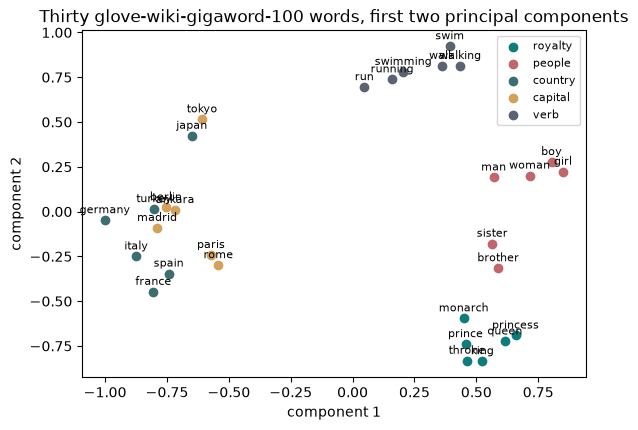

In [24]:
from sklearn.decomposition import PCA

BOOK_PROJECTION = {
    "king": (0.524, -0.835, "royalty"),
    "queen": (0.615, -0.725, "royalty"),
    "prince": (0.456, -0.74, "royalty"),
    "princess": (0.658, -0.692, "royalty"),
    "monarch": (0.449, -0.596, "royalty"),
    "throne": (0.462, -0.832, "royalty"),
    "man": (0.57, 0.191, "people"),
    "woman": (0.715, 0.201, "people"),
    "boy": (0.804, 0.277, "people"),
    "girl": (0.85, 0.223, "people"),
    "brother": (0.588, -0.316, "people"),
    "sister": (0.564, -0.179, "people"),
    "france": (-0.805, -0.448, "country"),
    "italy": (-0.874, -0.25, "country"),
    "spain": (-0.743, -0.346, "country"),
    "germany": (-1.0, -0.048, "country"),
    "japan": (-0.65, 0.423, "country"),
    "turkey": (-0.802, 0.014, "country"),
    "paris": (-0.572, -0.242, "capital"),
    "rome": (-0.542, -0.299, "capital"),
    "madrid": (-0.79, -0.091, "capital"),
    "berlin": (-0.754, 0.024, "capital"),
    "tokyo": (-0.608, 0.515, "capital"),
    "ankara": (-0.717, 0.009, "capital"),
    "walk": (0.359, 0.813, "verb"),
    "walking": (0.434, 0.813, "verb"),
    "swim": (0.393, 0.923, "verb"),
    "swimming": (0.205, 0.78, "verb"),
    "run": (0.047, 0.695, "verb"),
    "running": (0.16, 0.738, "verb"),
}

words30 = list(BOOK_PROJECTION)
X30 = np.array([g[w] for w in words30])
pca = PCA(n_components=2).fit(X30)
Z = pca.transform(X30)
Z = Z / np.abs(Z).max()
book_xy = np.array([BOOK_PROJECTION[w][:2] for w in words30])
for axis in range(2):                                  # a component's sign is arbitrary
    if np.corrcoef(Z[:, axis], book_xy[:, axis])[0, 1] < 0:
        Z[:, axis] *= -1
vs_book("variance kept by 2 components, %", 100 * pca.explained_variance_ratio_.sum(), 37.5, "{:.1f}",
        note=GLOVE_NOTE)
print(f"largest coordinate difference from the widget: {np.abs(Z - book_xy).max():.4f}")

colours = {"royalty": "#0E7C7B", "people": "#C1666B", "country": "#3C6E71", "capital": "#D4A15A", "verb": "#5B6272"}
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for group, colour in colours.items():
    members = [i for i, w in enumerate(words30) if BOOK_PROJECTION[w][2] == group]
    ax.scatter(Z[members, 0], Z[members, 1], color=colour, label=group)
    for i in members:
        ax.annotate(words30[i], Z[i], textcoords="offset points", xytext=(0, 5), ha="center", fontsize=8)
ax.set_xlabel("component 1")
ax.set_ylabel("component 2")
ax.set_title(f"Thirty {GLOVE_NAME} words, first two principal components")
ax.legend(fontsize=8)
plt.show()

Read the picture with the chapter's caution: the components are chosen to separate
exactly these thirty points, and they keep only about a third of the variance. Every
number in the chapter is computed in 100 dimensions, never from a projection like this.

## 6. fastText: words made of pieces

[Chapter section](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/03-embeddings.html#fasttext-words-made-of-pieces). fastText represents a word as the sum
of its character n-grams plus, if the model saw it, a vector for the whole word. First the
arithmetic from the chapter's figure: `pumps` in 3-grams, and the claim that with
fastText's default sizes 3 to 6 an unseen word like `pumpage` decomposes into 22 pieces.
Then the widget's default pair of Turkish words.

In [25]:
def char_ngrams(word, n):
    w = f"<{word}>"
    return [w[i:i + n] for i in range(len(w) - n + 1)]


print("pumps, 3-grams:  ", char_ngrams("pumps", 3), "+ the word <pumps>")
print("pumpage, 3-grams:", char_ngrams("pumpage", 3))
shared = set(char_ngrams("pumps", 3)) & set(char_ngrams("pumpage", 3))
print("shared 3-grams:  ", sorted(shared))
vs_book("pumpage, n-grams of size 3 to 6", sum(len(char_ngrams("pumpage", n)) for n in range(3, 7)), 22)

grams = char_ngrams("kitaplarımızdaki", 4)
also = set(char_ngrams("kitaplar", 4))
print(f"\nkitaplarımızdaki: {len(grams)} n-grams of size 4, "
      f"{sum(gm in also for gm in grams)} of them also in 'kitaplar':")
print(grams)

pumps, 3-grams:   ['<pu', 'pum', 'ump', 'mps', 'ps>'] + the word <pumps>
pumpage, 3-grams: ['<pu', 'pum', 'ump', 'mpa', 'pag', 'age', 'ge>']
shared 3-grams:   ['<pu', 'pum', 'ump']
pumpage, n-grams of size 3 to 6      this run         22   book         22   same as the book

kitaplarımızdaki: 15 n-grams of size 4, 6 of them also in 'kitaplar':
['<kit', 'kita', 'itap', 'tapl', 'apla', 'plar', 'ları', 'arım', 'rımı', 'ımız', 'mızd', 'ızda', 'zdak', 'daki', 'aki>']


### The corpora: a substitute, not the book's

The chapter compares "two Wikipedia samples of comparable size, one Turkish and one
English". It does not say which samples, how they were drawn, or how they were tokenized,
so its corpus numbers cannot be reproduced here. This notebook builds the closest reading
it can:

- **Samples.** The first articles, in dataset order, of the Hugging Face `wikimedia/wikipedia`
  dumps `20231101.tr` and `20231101.en`, cut at *exactly* the chapter's token counts:
  1,458,213 Turkish and 1,828,840 English tokens. Fetched through the Hugging Face
  dataset viewer API, 100 articles per request, and cached as JSON. Wikipedia text is
  licensed CC BY-SA; the dataset card lists CC BY-SA 3.0 and the GFDL.
- **Lines** are the non-empty lines of the article text.
- **Tokens** are `\w+` runs after lowercasing. For Turkish the lowercasing is done the
  Turkish way (`I`→`ı`, `İ`→`i`), as in chapter 4.

Because both samples match the chapter's token counts, the type counts are comparable in
size. They are still different text, so every book value below is shown for context and
marked *not comparable*.

**What to look at:** Turkish produces far more distinct word forms from *fewer* tokens.

In [26]:
ROWS_API = "https://datasets-server.huggingface.co/rows"
TR_LOWER = str.maketrans({"I": "ı", "İ": "i"})


def tr_tokenize(text):
    return re.findall(r"\w+", text.translate(TR_LOWER).lower())


def en_tokenize(text):
    return re.findall(r"\w+", text.lower())


def wikipedia_sample(config, n_tokens, tokenize):
    """The first articles of a wikimedia/wikipedia dump, enough to reach n_tokens. Cached."""
    path = CACHE / f"wikipedia-{config}-first-{n_tokens}-tokens.json"
    if not path.exists():
        texts, seen, offset = [], 0, 0
        while seen < n_tokens:
            params = {"dataset": "wikimedia/wikipedia", "config": config, "split": "train",
                      "offset": offset, "length": 100}
            for attempt in range(6):                        # the viewer API has transient 429s and 502s
                r = requests.get(ROWS_API, params=params, timeout=120)
                if r.status_code != 429 and r.status_code < 500:
                    break
                time.sleep(5 * 2**attempt)
            r.raise_for_status()
            for item in r.json()["rows"]:
                texts.append(item["row"]["text"])
                seen += len(tokenize(item["row"]["text"]))
                if seen >= n_tokens:
                    break
            offset += 100
        path.write_text(json.dumps(texts, ensure_ascii=False), encoding="utf-8")
    raw_json = path.read_bytes()
    print(f"{config}: {len(json.loads(raw_json)):,} articles cached, {len(raw_json) / 1e6:.1f} MB, "
          f"sha256 {hashlib.sha256(raw_json).hexdigest()[:12]}")
    return json.loads(raw_json)


def to_lines(texts, tokenize, n_tokens):
    """Tokenized non-empty lines, cut at exactly n_tokens."""
    out, used = [], 0
    for text in texts:
        for line in text.split("\n"):
            toks = tokenize(line)[: n_tokens - used]
            if toks:
                out.append(toks)
                used += len(toks)
            if used >= n_tokens:
                return out
    return out


tr_lines = to_lines(wikipedia_sample("20231101.tr", 1_458_213, tr_tokenize), tr_tokenize, 1_458_213)
en_lines = to_lines(wikipedia_sample("20231101.en", 1_828_840, en_tokenize), en_tokenize, 1_828_840)

NOTE_CORPUS = "different corpus"
BOOK_CORPORA = {"turkish": (103_040, 1_458_213, 138_578), "english": (44_079, 1_828_840, 78_140)}
print("\n### corpora")
for name, lines in [("turkish", tr_lines), ("english", en_lines)]:
    n_tok = sum(map(len, lines))
    n_types = len({w for line in lines for w in line})
    b_lines, b_tok, b_types = BOOK_CORPORA[name]
    print(f"  {name:<8} {len(lines):>7} lines {n_tok:>10} tokens {n_types:>9} types")
    vs_book(f"    {name} tokens", n_tok, b_tok, "{:,}")
    vs_book(f"    {name} types", n_types, b_types, "{:,}", note=NOTE_CORPUS)
    vs_book(f"    {name} lines", len(lines), b_lines, "{:,}", note=NOTE_CORPUS)

20231101.tr: 1,486 articles cached, 11.5 MB, sha256 ed6a2c5e19dd


20231101.en: 434 articles cached, 11.6 MB, sha256 2b19e767f302

### corpora
  turkish   116120 lines    1458213 tokens    134380 types
    turkish tokens                   this run  1,458,213   book  1,458,213   same as the book
    turkish types                    this run    134,380   book    138,578   not comparable: different corpus
    turkish lines                    this run    116,120   book    103,040   not comparable: different corpus


  english    56235 lines    1828840 tokens     81619 types
    english tokens                   this run  1,828,840   book  1,828,840   same as the book
    english types                    this run     81,619   book     78,140   not comparable: different corpus
    english lines                    this run     56,235   book     44,079   not comparable: different corpus


The chapter's three measurements of the vocabulary bill: how fast new word forms keep
arriving, how much of the vocabulary is seen exactly once, and the out-of-vocabulary rate
when you train on the first 90% of the tokens and test on the last 10%.

The last measurement is sensitive to *how* the 10% is chosen, so the cell adds a second
version, labelled as ours: 10% of the *lines* drawn at random with a fixed seed.

In [27]:
BOOK_GROWTH = {"turkish": "250k:45688  500k:73435  750k:97412  1000k:112644  1250k:126389",
               "english": "250k:22869  500k:34016  750k:42854  1000k:52347  1250k:60178"}
BOOK_HAPAX = {"turkish": "50.0% of types are hapax (69296 of 138578)",
              "english": "46.7% of types are hapax (36503 of 78140)"}
BOOK_OOV = {"turkish": "7.33% of tokens unseen, 28.99% of types unseen",
            "english": "4.72% of tokens unseen, 23.29% of types unseen"}


def oov_rates(train_tokens, test_tokens):
    seen = set(train_tokens)
    test_types = set(test_tokens)
    return (100 * sum(w not in seen for w in test_tokens) / len(test_tokens),
            100 * sum(w not in seen for w in test_types) / len(test_types))


results = {}
for name, lines in [("turkish", tr_lines), ("english", en_lines)]:
    stream = [w for line in lines for w in line]
    seen, growth = set(), []
    for i, w in enumerate(stream, start=1):
        seen.add(w)
        if i % 250_000 == 0 and len(growth) < 5:
            growth.append(f"{i // 1000}k:{len(seen)}")
    type_counts = Counter(stream)
    hapax = sum(1 for n in type_counts.values() if n == 1)
    cut = int(0.9 * len(stream))
    last_tok, last_typ = oov_rates(stream[:cut], stream[cut:])
    line_rng = np.random.default_rng(0)
    held_out = line_rng.random(len(lines)) < 0.1
    rand_tok, rand_typ = oov_rates([w for l, h in zip(lines, held_out) if not h for w in l],
                                   [w for l, h in zip(lines, held_out) if h for w in l])
    results[name] = (growth, hapax, len(type_counts), last_tok, last_typ, rand_tok, rand_typ)

print("### vocabulary growth: new word forms per million tokens")
for name, r in results.items():
    vs_book_line(name, "  ".join(r[0]), BOOK_GROWTH[name], note=NOTE_CORPUS)
print("\n### the tail: how much of the vocabulary is seen exactly once")
for name, r in results.items():
    vs_book_line(name, f"{100 * r[1] / r[2]:.1f}% of types are hapax ({r[1]} of {r[2]})", BOOK_HAPAX[name],
                 note=NOTE_CORPUS)
print("\n### out-of-vocabulary rate: train on 90%, test on the last 10%")
for name, r in results.items():
    vs_book_line(name, f"{r[3]:.2f}% of tokens unseen, {r[4]:.2f}% of types unseen", BOOK_OOV[name],
                 note=NOTE_CORPUS)
print("\n### ours, not the book's: hold out a random 10% of lines instead")
for name, r in results.items():
    print(f"  {name:<12} {r[5]:.2f}% of tokens unseen, {r[6]:.2f}% of types unseen")

### vocabulary growth: new word forms per million tokens
  turkish      250k:45801  500k:73651  750k:96914  1000k:111998  1250k:125686
    book       250k:45688  500k:73435  750k:97412  1000k:112644  1250k:126389   [not comparable: different corpus]
  english      250k:23856  500k:36038  750k:45401  1000k:53461  1250k:63178
    book       250k:22869  500k:34016  750k:42854  1000k:52347  1250k:60178   [not comparable: different corpus]

### the tail: how much of the vocabulary is seen exactly once
  turkish      50.5% of types are hapax (67796 of 134380)
    book       50.0% of types are hapax (69296 of 138578)   [not comparable: different corpus]
  english      47.0% of types are hapax (38399 of 81619)
    book       46.7% of types are hapax (36503 of 78140)   [not comparable: different corpus]

### out-of-vocabulary rate: train on 90%, test on the last 10%
  turkish      4.21% of tokens unseen, 21.87% of types unseen
    book       7.33% of tokens unseen, 28.99% of types unseen   [not

**Reading it.** Growth and hapax share come out close to the chapter's on a different
sample of the same encyclopedia: at a million tokens Turkish has seen more than twice as
many forms as English, and the curve is not flattening.

The out-of-vocabulary rate is the fragile one. Holding out the *last* 10% of this sample,
English comes out *above* Turkish, the reverse of the chapter. The English sample is 434
long articles, so its last tenth is a few dozen articles on new topics, full of names the
first 90% never mentioned. Holding out random lines removes that topic shift, and the
chapter's ordering comes back: Turkish well above English. The chapter's samples probably
mixed topics more evenly. Either way, a held-out OOV rate measures the split as well as
the language, so say how the held-out text was chosen whenever you quote one.

### word2vec and fastText on the same Turkish sample

The chapter trains both models on its Turkish sample but does not print the settings.
The next cell uses chapter 4's `gensim` settings (skip-gram, window 5, five negatives,
n-grams of 3 to 6, 500,000 buckets, one worker, seed 42), with `min_count` and `epochs`
left at gensim's defaults of 5 and 5. We tried two settings. Chapter 4's own `min_count=2,
epochs=10` gave neighbour lists further from this chapter's, so this pair was kept. A
second fastText model on the English sample handles the typo examples. Training takes about
a minute in all.

In [28]:
from gensim.models import FastText, Word2Vec

SETTINGS = dict(vector_size=100, window=5, min_count=5, sg=1, negative=5, epochs=5, workers=1, seed=42)
start = time.perf_counter()
with quiet_gensim("three models"):
    w2v_tr = Word2Vec(tr_lines, **SETTINGS)
    ft_tr = FastText(tr_lines, **SETTINGS, min_n=3, max_n=6, bucket=500_000)
    ft_en = FastText(en_lines, **SETTINGS, min_n=3, max_n=6, bucket=500_000)
print(f"trained in {time.perf_counter() - start:.0f}s; vocabularies: Turkish {len(w2v_tr.wv):,}, "
      f"English {len(ft_en.wv):,}")


def top(model, word, k):
    return ", ".join(f"{w} {s:.2f}" for w, s in model.wv.most_similar(word, topn=k))


print("\n### a word the corpus never saw")
BOOK_UNSEEN = {"kitaplarımızdaki": "kitapları 0.91, kitapların 0.91, kitaplıkları 0.90, kitaplarda 0.90",
               "bilgisayarcılık": "bilgisayara 0.96, bilgisayarlı 0.96, bilgisayar 0.96, bilgisayarı 0.96"}
for word, book_line in BOOK_UNSEEN.items():
    print(f"  {word:<18} in word2vec vocab: {word in w2v_tr.wv.key_to_index}   "
          f"in fastText vocab: {word in ft_tr.wv.key_to_index}")
    vs_book_line("  fastText", top(ft_tr, word, 4), book_line, note=NOTE_CORPUS)
    try:
        w2v_tr.wv[word]
        print("    word2vec answers (the word is in this sample's vocabulary)")
    except KeyError:
        print("    word2vec raises: KeyError")

print("\n### typos, fastText on the English sample")
BOOK_TYPOS = {"philosphy": "philosophy 0.96, philosophie 0.95, philosophies 0.94, philology 0.94, philo 0.93",
              "governmentt": "government 0.98, governments 0.94, governmental 0.93, governs 0.91, govern 0.91"}
for word, book_line in BOOK_TYPOS.items():
    print(f"  {word:<15} in vocab: {word in ft_en.wv.key_to_index}")
    vs_book_line("  fastText", top(ft_en, word, 5), book_line, note=NOTE_CORPUS)

(three models: gensim printed its 'Exception ignored in our_dot_float' note 16 times)
trained in 58s; vocabularies: Turkish 26,941, English 22,179

### a word the corpus never saw
  kitaplarımızdaki   in word2vec vocab: False   in fastText vocab: False
    fastText   kitapları 0.92, kitapların 0.90, kitaplar 0.90, kitaplara 0.89
    book       kitapları 0.91, kitapların 0.91, kitaplıkları 0.90, kitaplarda 0.90   [not comparable: different corpus]
    word2vec raises: KeyError
  bilgisayarcılık    in word2vec vocab: False   in fastText vocab: False
    fastText   bilgisayara 0.97, bilgisayarlı 0.97, bilgisayar 0.97, bilgisayarı 0.96
    book       bilgisayara 0.96, bilgisayarlı 0.96, bilgisayar 0.96, bilgisayarı 0.96   [not comparable: different corpus]
    word2vec raises: KeyError

### typos, fastText on the English sample
  philosphy       in vocab: False
    fastText   philosophie 0.96, philosophy 0.96, philology 0.94, philosophies 0.94, philostratus 0.93
    book       philosophy 0

### The price of subwords

The chapter's two morphology examples: `kitap` (book), where fastText returns inflections
and word2vec returns semantic neighbours, and `yaz` (summer, also "write"), where fastText
drowns in spelling. Then its single measured price, the similarity between `kitap` and the
unrelated `kitle` (mass, crowd).

In [29]:
print("### morphology: does fastText put inflected forms together?")
BOOK_MORPH = {("ft", "kitap"): "kitapta 0.96, kitaba 0.95, kitab 0.94, kitabın 0.94, kitabı 0.93",
              ("w2v", "kitap"): "eseri 0.81, makale 0.80, eseriyle 0.80, kitabın 0.80, kitaplar 0.79",
              ("ft", "yaz"): "yao 0.78, yağ 0.77, yağdı 0.77, yayoi 0.76, yay 0.75",
              ("w2v", "yaz"): "kış 0.86, olimpiyatları 0.84, aylarında 0.83, gündönümü 0.80"}
for (kind, word), book_line in BOOK_MORPH.items():
    model = ft_tr if kind == "ft" else w2v_tr
    k = len(book_line.split(", "))
    vs_book_line(f"{kind:<3} {word}", top(model, word, k), book_line, note=NOTE_CORPUS)

print("\n### the price, measured")
vs_book("kitap / kitle, fastText", float(ft_tr.wv.similarity("kitap", "kitle")), 0.667, "{:+.3f}", note=NOTE_CORPUS)
vs_book("kitap / kitle, word2vec", float(w2v_tr.wv.similarity("kitap", "kitle")), 0.446, "{:+.3f}", note=NOTE_CORPUS)

### morphology: does fastText put inflected forms together?
  ft  kitap    kitapta 0.96, kitab 0.95, kitabın 0.95, kitabı 0.94, kitaplık 0.93
    book       kitapta 0.96, kitaba 0.95, kitab 0.94, kitabın 0.94, kitabı 0.93   [not comparable: different corpus]
  w2v kitap    makale 0.82, eseriyle 0.80, kitabın 0.78, yazılan 0.78, eseri 0.77
    book       eseri 0.81, makale 0.80, eseriyle 0.80, kitabın 0.80, kitaplar 0.79   [not comparable: different corpus]
  ft  yaz      yarık 0.76, yağ 0.75, yayoi 0.75, yay 0.75, yağdı 0.74
    book       yao 0.78, yağ 0.77, yağdı 0.77, yayoi 0.76, yay 0.75   [not comparable: different corpus]
  w2v yaz      kış 0.90, olimpiyatları 0.87, aylarında 0.77, atlanta 0.77
    book       kış 0.86, olimpiyatları 0.84, aylarında 0.83, gündönümü 0.80   [not comparable: different corpus]

### the price, measured
kitap / kitle, fastText              this run     +0.714   book     +0.667   not comparable: different corpus
kitap / kitle, word2vec              this 

**Reading it.** On a different Wikipedia sample, and with settings we had to guess, the
chapter's qualitative findings all reappear. fastText answers for Turkish words it never
saw, and for English typos. It groups inflections of `kitap` where word2vec finds `makale`
and `eser`. It returns spelling neighbours such as `yağ` and `yay` for `yaz`, where word2vec
finds `kış` (winter). And it scores `kitap`/`kitle` well above word2vec does. The exact
lists differ, as they must on different text.

The chapter's rule: **subword models trade semantic precision for morphological
coverage.**

## 7. Documents as vectors

[Chapter section](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/03-embeddings.html#documents-as-vectors). Same four newsgroups, same train/test split and
same logistic regression as [chapter 2](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/02-text-as-data.html). The 20 Newsgroups posts were collected by
Ken Lang; scikit-learn downloads them from their original host, and no licence is stated for
them.

The chapter shows only its `average` function, so the rest is a reading of its prose, and
each piece is checked against a number the chapter prints:

- **The TF-IDF baseline** is chapter 2's `TfidfVectorizer(stop_words="english")` row. Its
  feature count, 32,014, is the fingerprint.
- **The tokenizer** for the dense methods is not stated. The chapter's coverage numbers
  identify one: `re.findall(r"[a-z]+", text.lower())` on the training posts gives exactly
  its 27,681 types and 23,395 covered. The cell checks that first.

In [30]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline

cats = ["sci.med", "sci.space", "rec.autos", "talk.politics.guns"]
drop = ("headers", "footers", "quotes")
NG_HOME = str(CACHE / "scikit_learn_data")
train = fetch_20newsgroups(subset="train", categories=cats, remove=drop, data_home=NG_HOME)
test = fetch_20newsgroups(subset="test", categories=cats, remove=drop, data_home=NG_HOME)
vs_book("training documents", len(train.data), 2_327, "{:,}")
vs_book("test documents", len(test.data), 1_550, "{:,}")


def tokenize_news(text):
    return re.findall(r"[a-z]+", text.lower())


train_tok = [tokenize_news(t) for t in train.data]
test_tok = [tokenize_news(t) for t in test.data]

print("\n### coverage: how much of the corpus does glove actually know?")
type_counts = Counter(w for doc in train_tok for w in doc)
covered_types = sum(1 for w in type_counts if w in g.key_to_index)
covered_tokens = sum(n for w, n in type_counts.items() if w in g.key_to_index)
vs_book("types in the training posts", len(type_counts), 27_681, "{:,}")
vs_book("types covered", covered_types, 23_395, "{:,}", note=GLOVE_NOTE)
vs_book("types covered, %", 100 * covered_types / len(type_counts), 84.5, "{:.1f}", note=GLOVE_NOTE)
vs_book("tokens covered, %", 100 * covered_tokens / sum(type_counts.values()), 98.6, "{:.1f}", note=GLOVE_NOTE)

training documents                   this run      2,327   book      2,327   same as the book
test documents                       this run      1,550   book      1,550   same as the book

### coverage: how much of the corpus does glove actually know?
types in the training posts          this run     27,681   book     27,681   same as the book
types covered                        this run     23,395   book     23,395   same as the book
types covered, %                     this run       84.5   book       84.5   same as the book
tokens covered, %                    this run       98.6   book       98.6   same as the book


Now the table. The remaining readings:

- **Averaged GloVe** is the chapter's `average` function, unchanged.
- **IDF-weighted averaged GloVe** weights each token's vector by its IDF from the TF-IDF
  baseline's vectorizer. Words that vectorizer does not know (stop words, one-letter
  tokens) get weight 0. This reproduces the chapter's 0.822; so does the same thing
  without stop words, so it is a reading that fits, not a recovered listing. It is also
  fragile at the third decimal: `np.average` works in float64, and the same weighted
  average computed in float32 scores 0.823, one test document different.
- **doc2vec** is `Doc2Vec(dm=0, vector_size=100, epochs=40)` with gensim's other defaults,
  one worker and seed 0. Test documents have no row, so their vectors come from
  `infer_vector`. One reproducibility trap: `infer_vector` seeds each new vector from
  Python's built-in `hash()` of the document text, and that hash changes every time Python
  starts unless `PYTHONHASHSEED` is set. So the chapter's own doc2vec number cannot be
  rerun exactly by anyone. The cell swaps in a stable hash (CRC-32) so that this notebook's
  number is repeatable.
- **Averaged GloVe + doc2vec** concatenates the two 100-dimensional vectors.

Every classifier is `LogisticRegression(max_iter=2000, random_state=0)`, as in chapter 2.

In [31]:
import gensim.models.doc2vec as doc2vec_module
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from gensim.models.keyedvectors import pseudorandom_weak_vector


def stable_weak_vector(size, seed_string=None, hashfxn=None):
    """gensim's own initialiser for inferred vectors, with a hash that is the same in every process."""
    return pseudorandom_weak_vector(size, seed_string=seed_string,
                                    hashfxn=lambda s: zlib.crc32(s.encode("utf-8")))


doc2vec_module.pseudorandom_weak_vector = stable_weak_vector


def average(docs):
    out = np.zeros((len(docs), g.vector_size), dtype=np.float32)
    for i, d in enumerate(docs):
        vs = [g[w] for w in d if w in g.key_to_index]
        if vs:
            out[i] = np.mean(vs, axis=0)
    return out


def idf_average(docs, idf):
    out = np.zeros((len(docs), g.vector_size), dtype=np.float32)
    for i, d in enumerate(docs):
        words = [w for w in d if w in g.key_to_index and idf.get(w, 0.0) > 0]
        if words:
            out[i] = np.average([g[w] for w in words], axis=0, weights=[idf[w] for w in words])
    return out


def fit_score(X_train, X_test):
    clf = LogisticRegression(max_iter=2000, random_state=0).fit(X_train, train.target)
    return accuracy_score(test.target, clf.predict(X_test))


def doc2vec_vectors(seed):
    model = Doc2Vec([TaggedDocument(d, [i]) for i, d in enumerate(train_tok)],
                    dm=0, vector_size=100, epochs=40, workers=1, seed=seed)
    return (np.array([model.dv[i] for i in range(len(train_tok))]),
            np.array([model.infer_vector(d) for d in test_tok]))


start = time.perf_counter()
baseline = make_pipeline(TfidfVectorizer(stop_words="english"), LogisticRegression(max_iter=2000, random_state=0))
baseline.fit(train.data, train.target)
acc_tfidf = accuracy_score(test.target, baseline.predict(test.data))
n_features = len(baseline[0].get_feature_names_out())

avg_train, avg_test = average(train_tok), average(test_tok)
acc_avg = fit_score(avg_train, avg_test)
idf = dict(zip(baseline[0].get_feature_names_out(), baseline[0].idf_))
acc_idf = fit_score(idf_average(train_tok, idf), idf_average(test_tok, idf))
with quiet_gensim("doc2vec, seed 0"):
    d2v_train, d2v_test = doc2vec_vectors(seed=0)
acc_d2v = fit_score(d2v_train, d2v_test)
acc_both = fit_score(np.hstack([avg_train, d2v_train]), np.hstack([avg_test, d2v_test]))

print("\n### documents as vectors: four ways")
rows = [("tf-idf (chapter 2 baseline)", acc_tfidf, n_features, 0.853, 32_014, None),
        ("averaged glove", acc_avg, g.vector_size, 0.820, 100, GLOVE_NOTE),
        ("idf-weighted averaged glove", acc_idf, g.vector_size, 0.822, 100, GLOVE_NOTE),
        ("doc2vec (PV-DBOW, 40 epochs)", acc_d2v, 100, 0.839, 100, None),
        ("averaged glove + doc2vec", acc_both, g.vector_size + 100, 0.845, 200, GLOVE_NOTE)]
for name, acc, dims, book_acc, book_dims, note in rows:
    print(f"{name:<34} accuracy {acc:.3f}   dimensions {dims:>7}")
print()
for name, acc, dims, book_acc, book_dims, note in rows:
    vs_book(f"{name}", acc, book_acc, "{:.3f}", note=note)
vs_book("tf-idf features", n_features, 32_014, "{:,}")
print(f"\n({time.perf_counter() - start:.0f}s)")

(doc2vec, seed 0: gensim printed its 'Exception ignored in our_dot_float' note 4 times)

### documents as vectors: four ways
tf-idf (chapter 2 baseline)        accuracy 0.853   dimensions   32014
averaged glove                     accuracy 0.820   dimensions     100
idf-weighted averaged glove        accuracy 0.822   dimensions     100
doc2vec (PV-DBOW, 40 epochs)       accuracy 0.830   dimensions     100
averaged glove + doc2vec           accuracy 0.839   dimensions     200

tf-idf (chapter 2 baseline)          this run      0.853   book      0.853   same as the book
averaged glove                       this run      0.820   book      0.820   same as the book
idf-weighted averaged glove          this run      0.822   book      0.822   same as the book
doc2vec (PV-DBOW, 40 epochs)         this run      0.830   book      0.839   DIFFERS from the book
averaged glove + doc2vec             this run      0.839   book      0.845   DIFFERS from the book
tf-idf features                      th

**How much does doc2vec move by itself?** The chapter warns that the doc2vec-over-averaging
gap is "about two standard errors on a single split". A cheaper source of variation is
the seed. The cell retrains doc2vec with two more seeds on the same split, then checks the
chapter's standard-error arithmetic and its "320 times fewer dimensions".

In [32]:
seed_scores = {0: acc_d2v}
with quiet_gensim("doc2vec, seeds 1 and 2"):
    for seed in [1, 2]:
        seed_scores[seed] = fit_score(*doc2vec_vectors(seed))
print("doc2vec accuracy by seed:", {s: round(a, 3) for s, a in seed_scores.items()},
      f"  range {100 * (max(seed_scores.values()) - min(seed_scores.values())):.1f} points")

n_test = len(test.data)
vs_book("standard error of an accuracy near 0.83", math.sqrt(0.83 * 0.17 / n_test), 0.010, "{:.3f}")
vs_book("tf-idf features / 100 dimensions", 32_014 / 100, 320, "{:.0f}")

(doc2vec, seeds 1 and 2: gensim printed its 'Exception ignored in our_dot_float' note 5 times)
doc2vec accuracy by seed: {0: 0.83, 1: 0.836, 2: 0.834}   range 0.6 points
standard error of an accuracy near 0.83 this run      0.010   book      0.010   same as the book
tf-idf features / 100 dimensions     this run        320   book        320   same as the book


**Reading it.** The TF-IDF baseline, both GloVe averages and the coverage numbers
reproduce, including the feature count. The doc2vec rows do not. This notebook's reading
gives 0.830 and 0.839 where the chapter printed 0.839 and 0.845, and two more seeds move
doc2vec alone between 0.830 and 0.836. The settings are not in the chapter, and its own
number cannot be rerun exactly anyway, because of the hash. What
does survive is the chapter's ordering: **the sparse chapter-2 baseline beats every dense
method**, and the gap between TF-IDF and averaged GloVe (3.3 points) is the one that is
large against the standard error.

### What averaging destroys

The chapter's four lines, then its two printed results. "Identical" is read here as
`np.allclose`: the chapter says identical "to floating-point precision". A bit-for-bit
check is printed too, because it can come out differently. Adding the same float32 numbers
in a different order can change the last bit of the sum.

In [33]:
a = "the pump failed and the valve is fine".split()
b = "the valve failed and the pump is fine".split()
va = np.mean([g[w] for w in a], axis=0)
vb = np.mean([g[w] for w in b], axis=0)

print("### what averaging destroys")
cos_ab = float(va @ vb / (np.linalg.norm(va) * np.linalg.norm(vb)))
print(f"  cosine of the two averaged vectors: {cos_ab:.4f}")
print(f"  identical: {np.allclose(va, vb)}")
vs_book("cosine", cos_ab, 1.0, "{:.4f}")
vs_book("identical (np.allclose)", np.allclose(va, vb), True)
print(f"\nbit for bit (np.array_equal): {np.array_equal(va, vb)}; "
      f"largest difference {np.abs(va - vb).max():.1e}")

### what averaging destroys
  cosine of the two averaged vectors: 1.0000
  identical: True
cosine                               this run     1.0000   book     1.0000   same as the book
identical (np.allclose)              this run       True   book       True   same as the book

bit for bit (np.array_equal): False; largest difference 1.2e-07


## 8. The geometry has problems

[Chapter section](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/03-embeddings.html#the-geometry-has-problems). Three defects to be able to name.

### Cosine measures relatedness, not similarity

The chapter prints six cosines without code; `g.similarity` is the one-line reading.
**What to look at:** `increase`/`decrease` against `cat`/`dog`.

In [34]:
for a_w, b_w, book in [("good", "bad", 0.770), ("hot", "cold", 0.725), ("increase", "decrease", 0.881),
                       ("cat", "dog", 0.880), ("cat", "car", 0.311), ("teacher", "student", 0.808)]:
    vs_book(f"  {a_w:<10} {b_w:<10}", float(g.similarity(a_w, b_w)), book, "{:.3f}", note=GLOVE_NOTE)

  good       bad                     this run      0.770   book      0.770   same as the book
  hot        cold                    this run      0.725   book      0.725   same as the book
  increase   decrease                this run      0.881   book      0.881   same as the book
  cat        dog                     this run      0.880   book      0.880   same as the book
  cat        car                     this run      0.311   book      0.311   same as the book
  teacher    student                 this run      0.808   book      0.808   same as the book


### The space is not isotropic

[Chapter section](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/03-embeddings.html#the-space-is-not-isotropic). The chapter's code samples 4,000 of the
50,000 most frequent words and takes the cosine of every pair, about 8 million. The five
statistics after its code are our reading of how they were computed. "After subtracting
the mean" subtracts the sample's mean vector and rescales each vector to unit length
before taking cosines again. The chapter's identity, that the mean cosine and the norm of
the mean vector are the same number, is checked too.

The widget's histogram (bins 0.05 wide) is recomputed and compared bin by bin, and drawn as
a static figure.

pairs: 7,998,000
mean cosine between random word pairs this run      0.029   book      0.029   same as the book
std                                  this run      0.119   book      0.119   same as the book
share of pairs with cosine > 0, %    this run       56.9   book       56.9   same as the book
norm of the mean vector              this run      0.171   book      0.171   same as the book
after subtracting the mean, mean cosine this run     -0.000   book     -0.000   same as the book
identity (n |mean|^2 - 1) / (n - 1)  this run      0.029   book      0.029   same as the book



histogram: 60 of 60 bin counts identical to the book's widget


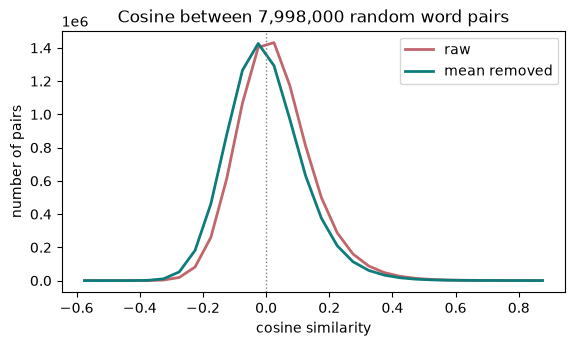

In [35]:
rng = np.random.default_rng(0)
M = g.get_normed_vectors()                       # (400000, 100), unit rows
sample = rng.choice(50_000, size=4000, replace=False)   # top 50k only
S = M[sample]
vals = (S @ S.T)[np.triu_indices(4000, k=1)]

S_centred = S - S.mean(axis=0)
S_centred /= np.linalg.norm(S_centred, axis=1, keepdims=True)
vals_centred = (S_centred @ S_centred.T)[np.triu_indices(4000, k=1)]
mean_norm = float(np.linalg.norm(S.mean(axis=0)))

print(f"pairs: {len(vals):,}")
vs_book("mean cosine between random word pairs", float(vals.mean()), 0.029, "{:.3f}", note=GLOVE_NOTE)
vs_book("std", float(vals.std()), 0.119, "{:.3f}", note=GLOVE_NOTE)
vs_book("share of pairs with cosine > 0, %", 100 * float((vals > 0).mean()), 56.9, "{:.1f}", note=GLOVE_NOTE)
vs_book("norm of the mean vector", mean_norm, 0.171, "{:.3f}", note=GLOVE_NOTE)
vs_book("after subtracting the mean, mean cosine", float(vals_centred.mean()) + 0.0, -0.000, "{:.3f}",
        note=GLOVE_NOTE)
vs_book("identity (n |mean|^2 - 1) / (n - 1)", (4000 * mean_norm**2 - 1) / 3999, 0.029, "{:.3f}", note=GLOVE_NOTE)

BOOK_HIST_CENTRES = [-0.575, -0.525, -0.475, -0.425, -0.375, -0.325, -0.275, -0.225, -0.175, -0.125, -0.075, -0.025, 0.025, 0.075, 0.125, 0.175, 0.225, 0.275, 0.325, 0.375, 0.425, 0.475, 0.525, 0.575, 0.625, 0.675, 0.725, 0.775, 0.825, 0.875]
BOOK_HIST_RAW = [5, 13, 30, 91, 466, 3292, 19099, 81573, 259774, 611031, 1067028, 1403084, 1431741, 1173616, 810182, 499591, 287900, 160168, 87639, 47704, 25435, 13127, 6695, 3425, 1979, 1188, 763, 513, 356, 244]
BOOK_HIST_CENTRED = [4, 5, 17, 172, 1543, 10528, 52224, 181429, 461214, 876010, 1264630, 1426436, 1292741, 971029, 630974, 375474, 210057, 113503, 61294, 32520, 16806, 8436, 4460, 2362, 1394, 884, 630, 437, 325, 227]

edges = np.round(np.arange(-0.6, 0.95, 0.05), 3)
hist_raw, _ = np.histogram(vals, bins=edges)
hist_centred, _ = np.histogram(vals_centred, bins=edges)
same_bins = sum(int(x) == y for x, y in zip(hist_raw, BOOK_HIST_RAW)) + \
            sum(int(x) == y for x, y in zip(hist_centred, BOOK_HIST_CENTRED))
print(f"\nhistogram: {same_bins} of {2 * len(BOOK_HIST_RAW)} bin counts identical to the book's widget"
      + ("" if GLOVE_FULL else "   [not comparable: skip mode uses glove-wiki-gigaword-50]"))

centres_x = (edges[:-1] + edges[1:]) / 2
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(centres_x, hist_raw, color="#C1666B", lw=2, label="raw")
ax.plot(centres_x, hist_centred, color="#0E7C7B", lw=2, label="mean removed")
ax.axvline(0, color="grey", ls=":", lw=1)
ax.set_xlabel("cosine similarity")
ax.set_ylabel("number of pairs")
ax.set_title(f"Cosine between {len(vals):,} random word pairs")
ax.legend()
plt.show()

**Reading it.** The raw distribution sits to the right of zero and centring moves it back.
The chapter's framing is the careful one: at a mean cosine of 0.029 the vectors are
tilted off centre, not crammed into a narrow cone. And the mean cosine and the mean-vector
norm are one piece of evidence, not two.

### Frequency leaks in

[Chapter section](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/03-embeddings.html#frequency-leaks-in). GloVe's vocabulary is sorted by frequency, so a
word's index is its frequency rank. The chapter prints mean vector norm by rank band, a
Spearman correlation over the top 100,000 words, and five words from common to rare with
their neighbours.

In [36]:
from scipy.stats import spearmanr

norms = np.linalg.norm(g.vectors, axis=1)
print("### mean vector norm by frequency rank")
for (lo, hi), book in zip([(0, 100), (100, 1000), (1000, 10000), (10000, 100000), (100000, 400000)],
                          [6.19, 5.85, 5.45, 4.99, 3.62]):
    vs_book(f"  rank {lo:>6}-{hi:<6}", float(norms[lo:hi].mean()), book, "{:.2f}", note=GLOVE_NOTE)
rho = spearmanr(np.log(np.arange(1, 100_001)), norms[:100_000]).statistic
vs_book("spearman(log rank, norm), top 100k", float(rho), -0.313, "{:.3f}", note=GLOVE_NOTE)

print("\n### quality falls with rarity (the book prints four or five neighbours per word)")
BOOK_RARE = {"water": (430, "natural 0.70, dry 0.68, salt 0.68, clean 0.68, drinking 0.67"),
             "turbine": (15747, "turbines 0.80, compressor 0.78, generator 0.72, engine 0.70"),
             "cavitation": (109044, "aliasing 0.56, barotrauma 0.54, attenuation 0.54, breakage 0.53"),
             "impeller": (124835, "armature 0.62, evaporator 0.61, nozzle 0.60, centrifugal 0.59"),
             "eutectic": (159022, "azeotrope 0.61, azeotropic 0.55, tiwai 0.54, bifurcation 0.52")}
for w, (book_rank, book_line) in BOOK_RARE.items():
    k = len(book_line.split(", "))
    vs_book(f"  rank of '{w}'", g.key_to_index[w], book_rank, "{}", note=GLOVE_NOTE)
    vs_book_line(f"  {w}", ", ".join(f"{a} {s:.2f}" for a, s in g.most_similar(w, topn=k)), book_line,
                 note=GLOVE_NOTE)

### mean vector norm by frequency rank
  rank      0-100                    this run       6.19   book       6.19   same as the book
  rank    100-1000                   this run       5.85   book       5.85   same as the book
  rank   1000-10000                  this run       5.45   book       5.45   same as the book
  rank  10000-100000                 this run       4.99   book       4.99   same as the book
  rank 100000-400000                 this run       3.62   book       3.62   same as the book
spearman(log rank, norm), top 100k   this run     -0.313   book     -0.313   same as the book

### quality falls with rarity (the book prints four or five neighbours per word)
  rank of 'water'                    this run        430   book        430   same as the book
    water      natural 0.70, dry 0.68, salt 0.68, clean 0.68, drinking 0.67   [same as the book]
  rank of 'turbine'                  this run      15747   book      15747   same as the book
    turbine    turbines 0.80, 

## 9. Bias is in the data, and the geometry records it

[Chapter section](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/03-embeddings.html#bias-is-in-the-data-and-the-geometry-records-it). The chapter projects
occupation words onto the `woman` − `man` axis. Its three lines are the computation; the
loop around them is ours.

In [37]:
axis = g["woman"] - g["man"]
axis /= np.linalg.norm(axis)

BOOK_BIAS = {"doctor": 0.109, "nurse": 0.329, "engineer": -0.123, "teacher": 0.152,
             "programmer": -0.083, "homemaker": 0.363, "scientist": -0.046, "receptionist": 0.281}
for w, book in BOOK_BIAS.items():
    proj = float(g[w] @ axis / np.linalg.norm(g[w]))
    side = "woman" if proj > 0 else "man"
    vs_book(f"  {w:<13} -> {side}", proj, book, "{:+.3f}", note=GLOVE_NOTE)

  doctor        -> woman             this run     +0.109   book     +0.109   same as the book
  nurse         -> woman             this run     +0.329   book     +0.329   same as the book
  engineer      -> man               this run     -0.123   book     -0.123   same as the book
  teacher       -> woman             this run     +0.152   book     +0.152   same as the book
  programmer    -> man               this run     -0.083   book     -0.083   same as the book
  homemaker     -> woman             this run     +0.363   book     +0.363   same as the book
  scientist     -> man               this run     -0.046   book     -0.046   same as the book
  receptionist  -> woman             this run     +0.281   book     +0.281   same as the book


**Reading it.** A single word pair defines this axis, which makes it easy to check by hand
and noisier than Bolukbasi et al.'s principal component over about ten pairs. The chapter's
intuition check applies to any version: bias that is not aligned with this one direction
is invisible to this test.

## 10. How do you know an embedding is any good?

[Chapter section](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/03-embeddings.html#how-do-you-know-an-embedding-is-any-good). Intrinsic evaluation on
three benchmarks. WordSim-353 and the Google analogy set ship with `gensim`'s test data.
SimLex-999 does not, so the cell downloads it from its authors' page (Hill, Reichart &
Korhonen, 2015; its README asks you to cite the paper and states no licence) and writes
the three columns `gensim` expects.

The three evaluation calls are the chapter's. The analogy evaluation takes about a minute.

**What to look at:** the gap between the two similarity benchmarks, and the spread of the
analogy categories around the headline number.

In [38]:
from gensim.test.utils import datapath

SIMLEX = CACHE / "SimLex-999.tsv"
if not SIMLEX.exists():
    r = requests.get("https://fh295.github.io/SimLex-999.zip", timeout=60)
    r.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        simlex_rows = z.read("SimLex-999/SimLex-999.txt").decode("utf-8").splitlines()
    assert simlex_rows[0].split("\t")[:4] == ["word1", "word2", "POS", "SimLex999"]
    SIMLEX.write_text("".join(f"{w1}\t{w2}\t{s}\n" for w1, w2, _, s, *_ in
                              (line.split("\t") for line in simlex_rows[1:])), encoding="utf-8")


def evaluate(kv):
    """The chapter's three calls, returned as one dict."""
    pear, spear, oov = kv.evaluate_word_pairs(datapath("wordsim353.tsv"))
    pear_s, spear_s, oov_s = kv.evaluate_word_pairs(str(SIMLEX))
    score, sections = kv.evaluate_word_analogies(datapath("questions-words.txt"))
    return {"ws_spearman": spear.statistic, "ws_pearson": pear[0], "ws_oov": oov,
            "sl_spearman": spear_s.statistic, "sl_pearson": pear_s[0], "sl_oov": oov_s,
            "analogy": score, "sections": sections}


start = time.perf_counter()
glove_eval = {GLOVE_NAME: evaluate(g)}
r = glove_eval[GLOVE_NAME]
print(f"({time.perf_counter() - start:.0f}s)\n")

print("### two similarity benchmarks that disagree on purpose")
print(f"  WordSim-353 (relatedness)    spearman {r['ws_spearman']:.3f}   pearson {r['ws_pearson']:.3f}   oov {r['ws_oov']:.1f}%")
print(f"  SimLex-999 (similarity)      spearman {r['sl_spearman']:.3f}   pearson {r['sl_pearson']:.3f}   oov {r['sl_oov']:.1f}%")
for label, key, book, fmt in [("WordSim-353 spearman", "ws_spearman", 0.533, "{:.3f}"),
                              ("WordSim-353 pearson", "ws_pearson", 0.548, "{:.3f}"),
                              ("WordSim-353 oov, %", "ws_oov", 0.0, "{:.1f}"),
                              ("SimLex-999 spearman", "sl_spearman", 0.296, "{:.3f}"),
                              ("SimLex-999 pearson", "sl_pearson", 0.324, "{:.3f}"),
                              ("SimLex-999 oov, %", "sl_oov", 0.1, "{:.1f}")]:
    vs_book(f"  {label}", r[key], book, fmt, note=GLOVE_NOTE)

with open(datapath("questions-words.txt"), encoding="utf-8") as f:
    question_lines = [line for line in f if not line.startswith(":")]
n_questions = len(question_lines)
categories = r["sections"][:-1]
scored = sum(len(s["correct"]) + len(s["incorrect"]) for s in categories)
n_correct = sum(len(s["correct"]) for s in categories)

print(f"\n### the Google analogy set, {n_questions} questions in {len(categories)} categories")
vs_book("  overall accuracy", r["analogy"], 0.633, "{:.3f}", note=GLOVE_NOTE)
BOOK_SECTIONS = {"capital-common-countries": (0.939, 506), "capital-world": (0.890, 4524), "currency": (0.152, 808),
                 "city-in-state": (0.308, 2467), "family": (0.816, 506), "gram1-adjective-to-adverb": (0.244, 992),
                 "gram2-opposite": (0.202, 812), "gram3-comparative": (0.791, 1332), "gram4-superlative": (0.543, 1122),
                 "gram5-present-participle": (0.695, 1056), "gram6-nationality-adjective": (0.879, 1599),
                 "gram7-past-tense": (0.554, 1560), "gram8-plural": (0.720, 1332), "gram9-plural-verbs": (0.584, 870)}
for s in categories:
    n = len(s["correct"]) + len(s["incorrect"])
    book_acc, book_n = BOOK_SECTIONS[s["section"]]
    vs_book(f"    {s['section']} ({n}q, {len(s['correct'])} right)", len(s["correct"]) / n, book_acc, "{:.3f}",
            note=GLOVE_NOTE if GLOVE_NOTE else (None if n == book_n else f"book has {book_n} questions"))
print()
vs_book("  questions in the file", n_questions, 19_544, "{:,}")
vs_book("  questions actually scored", scored, 19_486, "{:,}", note=GLOVE_NOTE)

(45s)

### two similarity benchmarks that disagree on purpose
  WordSim-353 (relatedness)    spearman 0.533   pearson 0.548   oov 0.0%
  SimLex-999 (similarity)      spearman 0.296   pearson 0.324   oov 0.1%
  WordSim-353 spearman               this run      0.533   book      0.533   same as the book
  WordSim-353 pearson                this run      0.548   book      0.548   same as the book
  WordSim-353 oov, %                 this run        0.0   book        0.0   same as the book
  SimLex-999 spearman                this run      0.296   book      0.296   same as the book
  SimLex-999 pearson                 this run      0.324   book      0.324   same as the book
  SimLex-999 oov, %                  this run        0.1   book        0.1   same as the book

### the Google analogy set, 19544 questions in 14 categories
  overall accuracy                   this run      0.633   book      0.633   same as the book
    capital-common-countries (506q, 475 right) this run      0.939   boo

**Reading it.** The similarity scores and the overall analogy accuracy reproduce, and so do
twelve of the fourteen categories. Two do not: `capital-world` and `gram2-opposite` each
come out one correct answer short of the chapter (4,024 of 4,524 is 0.889, where 4,025
would print 0.890; 163 of 812 is 0.201, where 164 would print 0.202). We looked for a near
tie that floating-point noise could flip. The closest decisions in those two categories are
separated by 1.3 × 10⁻⁵ and 2.8 × 10⁻⁴ in cosine, far above float noise, and the first of
them is one this run gets *right*. So the cause is not identified. The chapter's headline
0.633 is unaffected.

**The denominator problem, measured.** The chapter's warning box says the analogy scores
should be compared with `dummy4unknown=True`, which counts every out-of-vocabulary
question as wrong, and that "until that is run" both scores should be quoted with their
question counts. That flag only moves skipped questions into the wrong column, so its
result is the number of correct answers divided by all 19,544 questions. The next cell
computes it for GloVe, then trains nothing new but wraps the from-scratch NumPy vectors
from section 3 as `KeyedVectors` and scores them the same way, with the real flag as a
check. These `dummy4unknown` numbers are new measurements, not the book's.

In [39]:
from gensim.models import KeyedVectors

print(f"{GLOVE_NAME}: {n_correct:,} correct of {scored:,} scored -> {n_correct / scored:.3f};  "
      f"with dummy4unknown=True: {n_correct:,} of {n_questions:,} -> {n_correct / n_questions:.3f}")

print("\n### the same benchmarks on the vectors trained from scratch above")
if W2V_FULL:
    scratch = KeyedVectors(vector_size=D)
    scratch.add_vectors(vocab, E)
    rs = evaluate(scratch)
    s_categories = rs["sections"][:-1]
    s_scored = sum(len(s["correct"]) + len(s["incorrect"]) for s in s_categories)
    s_correct = sum(len(s["correct"]) for s in s_categories)
    print(f"  WordSim-353                  spearman {rs['ws_spearman']:.3f}   oov {rs['ws_oov']:.1f}%")
    print(f"  SimLex-999                   spearman {rs['sl_spearman']:.3f}   oov {rs['sl_oov']:.1f}%")
    print(f"  Google analogies             accuracy {rs['analogy']:.3f}")
    print(f"  (trained on {n_text8_tokens / 1e6:.1f}M tokens; glove saw 6 billion)\n")
    vs_book("  WordSim-353 spearman", rs["ws_spearman"], 0.627, "{:.3f}")
    vs_book("  WordSim-353 oov, %", rs["ws_oov"], 11.9, "{:.1f}")
    vs_book("  SimLex-999 spearman", rs["sl_spearman"], 0.268, "{:.3f}")
    vs_book("  SimLex-999 oov, %", rs["sl_oov"], 13.4, "{:.1f}")
    vs_book("  Google analogies accuracy", rs["analogy"], 0.200, "{:.3f}")

    dummy_score, _ = scratch.evaluate_word_analogies(datapath("questions-words.txt"), dummy4unknown=True)
    print(f"\n  from scratch: {s_correct:,} correct of {s_scored:,} scored -> {s_correct / s_scored:.3f};  "
          f"with dummy4unknown=True: {dummy_score:.3f}  (check: {s_correct / n_questions:.3f})")
else:
    print("SKIPPED: the from-scratch vectors come from the smoke run (ANLP_SKIP_HEAVY=1).")

glove-wiki-gigaword-100: 12,334 correct of 19,486 scored -> 0.633;  with dummy4unknown=True: 12,334 of 19,544 -> 0.631

### the same benchmarks on the vectors trained from scratch above


  WordSim-353                  spearman 0.627   oov 11.9%
  SimLex-999                   spearman 0.268   oov 13.4%
  Google analogies             accuracy 0.200
  (trained on 6.8M tokens; glove saw 6 billion)

  WordSim-353 spearman               this run      0.627   book      0.627   same as the book
  WordSim-353 oov, %                 this run       11.9   book       11.9   same as the book
  SimLex-999 spearman                this run      0.268   book      0.268   same as the book
  SimLex-999 oov, %                  this run       13.4   book       13.4   same as the book
  Google analogies accuracy          this run      0.200   book      0.200   same as the book



  from scratch: 1,852 correct of 9,282 scored -> 0.200;  with dummy4unknown=True: 0.095  (check: 0.095)


**Reading it.** The from-scratch model can attempt only 9,282 of the 19,544 analogy
questions; GloVe attempts 19,486. Counted over all 19,544, the from-scratch accuracy halves,
from 0.200 to 0.095, while GloVe's moves from 0.633 to 0.631. The WordSim-353 comparison in
the chapter's warning box has the same flaw: 0.627 on the 88% of pairs the small vocabulary
covers, against GloVe's 0.533 on all of them. That is
the chapter's point made concrete: **a model that refuses to answer looks more accurate
than one that answers and is sometimes mistaken.** Report coverage beside the score.

### Intuition check 1: why 300 dimensions and not 30 or 3,000?

The chapter's answer quotes the same benchmarks for the 50- and 100-dimensional GloVe
vectors. `glove-wiki-gigaword-50` is a 69.2 MB download; the 100-dimensional scores are
reused from above.

In [40]:
BOOK_DIMS = {"glove-wiki-gigaword-50": (0.503, 0.263, 0.464), "glove-wiki-gigaword-100": (0.533, 0.296, 0.633)}
if "glove-wiki-gigaword-50" not in glove_eval:
    start = time.perf_counter()
    g50 = api.load("glove-wiki-gigaword-50")
    glove_eval["glove-wiki-gigaword-50"] = evaluate(g50)
    del g50
    print(f"({time.perf_counter() - start:.0f}s)")
for name in ["glove-wiki-gigaword-50", "glove-wiki-gigaword-100"]:
    if name not in glove_eval:
        print(f"  {name}: SKIPPED (ANLP_SKIP_HEAVY=1)")
        continue
    r = glove_eval[name]
    print(f"  {name:<24} d={name.split('-')[-1]:<4} wordsim {r['ws_spearman']:.3f}  "
          f"simlex {r['sl_spearman']:.3f}  analogy {r['analogy']:.3f}")
    for label, value, book in zip(["wordsim", "simlex", "analogy"],
                                  [r["ws_spearman"], r["sl_spearman"], r["analogy"]], BOOK_DIMS[name]):
        vs_book(f"    {label}", value, book, "{:.3f}")

(46s)
  glove-wiki-gigaword-50   d=50   wordsim 0.503  simlex 0.263  analogy 0.464
    wordsim                          this run      0.503   book      0.503   same as the book
    simlex                           this run      0.263   book      0.263   same as the book
    analogy                          this run      0.464   book      0.464   same as the book
  glove-wiki-gigaword-100  d=100  wordsim 0.533  simlex 0.296  analogy 0.633
    wordsim                          this run      0.533   book      0.533   same as the book
    simlex                           this run      0.296   book      0.296   same as the book
    analogy                          this run      0.633   book      0.633   same as the book


## 11. Exercises

These follow [chapter 3's own exercises](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/03-embeddings.html#exercises), using the code above.

1. **Redo the toy space with a different window.** Set `W = 1`, then `W = 4`, in section 2
   and rerun that section. Which neighbour lists change? Say why a wider window makes the
   space more *topical* and a narrow one more *syntactic*. (Section 3 reuses the names
   `vocab`, `idx` and `V`, so rerun section 2 from its first cell.)
2. **Break the analogy.** Use `unfiltered(a, b, c)` from section 5 and
   `g.most_similar(positive=[a, c], negative=[b])` side by side. Find three analogies that
   work and three that fail. For each failure, decide whether the model lacks the
   knowledge or the arithmetic is the wrong tool. Then try 3CosMul, which `gensim` has as
   `g.most_similar_cosmul`.
3. **Audit your own domain.** Adapt the rare-word cell in section 8 to the twenty most
   important terms in your field: print each term's rank and five neighbours, grade each
   list good / plausible / nonsense, and report the correlation between rank and grade.
   Before you trust the analogy benchmark, rerun `evaluate_word_analogies` with
   `restrict_vocab=400_000`. The chapter notes that the default of 300,000 never lets the
   rarest 100,000 vectors be wrong.
4. **The Turkish vocabulary bill.** Section 6's `wikipedia_sample` and `oov_rates` work on
   any size. Double the Turkish sample and find how many tokens Turkish needs to reach the
   English OOV rate, under both held-out schemes. Explain why the two schemes can disagree
   about which language has the higher rate.
5. **Make averaging fail on purpose.** With section 7's averaging code, write two sentences
   from your own field with opposite operational meaning whose averaged GloVe vectors have
   cosine above 0.99. Then write the paragraph for a design review explaining why this
   representation must not gate that decision.
6. **Beat TF-IDF.** Change the table in section 7: tune doc2vec, or apply Arora et al.'s
   weighted average with the first principal component removed, or concatenate more
   representations. Before claiming a win, run McNemar's test on the paired predictions
   against the TF-IDF baseline, which is the test the chapter says it should get. Say
   whether the gain survives a different seed.
7. **Implement it.** Two extensions of the NumPy code in section 3. (a) Replace the
   clip-only update with the chapter's clean fix: divide each row's accumulated gradient by
   its `np.bincount` count, and see whether training survives learning rate 0.05, where the
   chapter's first run diverged. (b) Add CBOW and compare the two on rare words. Predict the
   direction of the difference before you run it. Train on fewer characters first: the full
   run takes about ten minutes.
8. **Measure a bias axis you care about.** Reuse section 9's projection with a word pair
   from your domain and twenty related terms, and report the ranking. Then apply Gonen and
   Goldberg's test: project the axis out and check whether a clustering, for example
   `sklearn.cluster.KMeans` with two clusters, still recovers the original groups.

The limits the chapter ends on are the reasons for the next chapters: word order
([chapter 6](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/06-language-models.html)), one vector per word form ([chapter 7](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/07-transformers.html)), and retrieval with contextual
vectors ([chapter 20](https://bbardakk.github.io/uygulamali-dogal-dil-isleme/en/chapters/20-rag.html)).

---

*Code in this notebook is MIT-licensed; the prose is CC BY 4.0. Data keeps its own terms:
GloVe vectors are PDDL (Stanford NLP, via gensim-data); `text8` is derived from English
Wikipedia (CC BY-SA), and gensim-data lists no licence for it; the Wikipedia samples are
CC BY-SA 3.0 / GFDL (`wikimedia/wikipedia` on Hugging Face); 20 Newsgroups (Ken Lang) and
SimLex-999 (Hill, Reichart & Korhonen) state no licence; WordSim-353 and the Google analogy
questions are read from gensim's bundled test data.*